In [1]:
import sys
import pandas as pd
import numpy as np
import itertools as itt
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import petab
from pypesto.store import OptimizationResultHDF5Reader
from pypesto import OptimizeResult, Result
from pypesto.C import MODE_RES
from pypesto.visualize import waterfall
from petab import get_simulation_conditions
from amici.petab_objective import rdatas_to_simulation_df

from mEncoder.autoencoder import MechanisticAutoEncoder
from process_data import training_samples, test_samples, Wildcards
from mEncoder.pretraining import (
    generate_cross_sample_pretraining_problem,
    generate_per_sample_pretraining_problems,
)
from mEncoder.petab_subproblem import load_petab
from mEncoder import (
    pretrain_dir,
    data_dir,
    fig_dir,
    apply_objective_settings,
    ESTIMATION_OUTFILE_TEMP,
)
from mEncoder.analysis import process_simulation
from mEncoder.plotting import plot_cross_samples
from training_configuration import ALPHAS, HIDDEN_LAYERS

from pathlib import Path

In [2]:
MODEL = "EGFR_MAPK"
DATA = "dream_cytof"
SAMPLES = "0_5"

In [3]:
samples_train = training_samples(Wildcards(DATA, SAMPLES))
samples_test = test_samples(Wildcards(DATA, SAMPLES))


def load_mae(dataset, hidden_layers, alpha):
    datafiles = (
        data_dir / f"{DATA}__{MODEL}__measurements.tsv",
        data_dir / f"{DATA}__{MODEL}__conditions.tsv",
        data_dir / f"{DATA}__{MODEL}__observables.tsv",
    )

    mae_train = MechanisticAutoEncoder(
        hidden_layers,
        datafiles,
        pathway_name=MODEL,
        samples=samples_train,
        par_modulation_scale=0.0,
    )

    if dataset == "train":
        return mae_train

    return MechanisticAutoEncoder(
        hidden_layers,
        datafiles,
        pathway_name=MODEL,
        samples=samples_test,
        par_modulation_scale=0.0,
        features=mae_train.features,
        imputer=mae_train.imputer,
        scaler=mae_train.scaler,
        pca=mae_train.pca,
    )

In [4]:
def evaluate_pretraining_per_sample(dataset, samples):
    evaluations = []

    for sample in samples:
        importer = generate_per_sample_pretraining_problems(
            load_petab(datafiles, "pw_" + MODEL, 0.0, [sample]),
            MODEL,
            f"{DATA}__{MODEL}",
            sample,
        )
        problem_sample = importer.create_problem()
        df = pd.read_csv(indir / f"{sample}.csv", index_col=[0])
        apply_objective_settings(problem_sample, MODEL)

        conditions = get_simulation_conditions(
            importer.petab_problem.measurement_df
        )
        ress = []
        fvals = []
        for ipar in range(len(df)):
            x = problem_sample.get_reduced_vector(
                df.values[ipar, :], problem_sample.x_free_indices
            )
            res = problem_sample.objective(x, return_dict=True)
            ress.append(res)
            fvals.append(res["fval"])

        process_simulation(
            evaluations,
            ress[np.argmin(fvals)],
            conditions,
            sample,
            "per_sample",
            0.0,
            0,
        )
    return pd.DataFrame(evaluations)

In [5]:
def load_optimize_result(problem, hidden_layers, alpha):
    def result_file(job_id) -> Path:
        output_prefix = Path(
            ESTIMATION_OUTFILE_TEMP.format(
                samples=SAMPLES,
                n_hidden=hidden_layers,
                alpha=alpha,
                job=job_id,
            )
        ).stem
        return indir / f"{output_prefix}.hdf5"

    result = OptimizeResult()
    for job in range(100):
        if not result_file(job).exists():
            continue
        r = (
            OptimizationResultHDF5Reader(str(result_file(job)))
            .read()
            .optimize_result.list[0]
        )
        r["id"] = str(job)
        result.append(r)

    if result.list is not None:
        result.sort()

        r = Result()
        r.optimize_result = result

        waterfall(r)
        plt.tight_layout()
        plt.savefig(
            outdir
            / f"{SAMPLES}_pretraining_cross_sample_a{alpha}_n{hidden_layers}_waterfall.pdf"
        )
    return result


def evaluate_petraining_cross_sample(dataset):
    evaluations = []
    results = []
    legends = []
    for alpha, hidden_layers in itt.product(ALPHAS, HIDDEN_LAYERS):
        mae = load_mae(dataset, hidden_layers, alpha)

        problem_cross_sample = generate_cross_sample_pretraining_problem(mae)
        apply_objective_settings(problem_cross_sample, MODEL)
        result = load_optimize_result(
            problem_cross_sample, hidden_layers, alpha
        )

        if result.list is None:
            continue
            t
        r = Result()
        r.optimize_result = result
        results.append(r)
        legends.append(f"{alpha} ({hidden_layers})")

        x_inner = problem_cross_sample.objective.infun(result.list[0]["x"])

        conditions = get_simulation_conditions(
            mae.petab_importer.petab_problem.measurement_df
        )

        obj = problem_cross_sample.objective.base_objective
        chi2prior = 0.0

        res = obj(x_inner, mode=MODE_RES, return_dict=True)

        if dataset == "train":
            samples = samples_train
        else:
            samples = samples_test

        for sample in samples:
            process_simulation(
                evaluations,
                res,
                conditions,
                sample,
                "cross_sample",
                alpha,
                hidden_layers,
            )

        simulation_df = rdatas_to_simulation_df(
            res["rdatas"],
            model=obj.amici_model,
            measurement_df=mae.petab_importer.petab_problem.measurement_df,
        )

        # plot_cross_samples(
        #    mae.petab_importer.petab_problem.measurement_df,
        #    simulation_df,
        #    outdir / 'pretrain_cross_samples',
        #    '__'.join([SAMPLES, str(hidden_layers), str(alpha), dataset])
        # )

        evaluations.append(
            {
                "chi2": chi2prior,
                "sample": "prior",
                "type": "cross_sample",
                "alpha": alpha,
                "layers": hidden_layers,
            }
        )
    waterfall(results=results, legends=legends)
    return pd.DataFrame(evaluations)

In [6]:
outdir = fig_dir / MODEL / DATA
indir = pretrain_dir / MODEL / DATA


def analyse(dataset):
    df = evaluate_petraining_cross_sample(dataset)
    df.to_csv(
        outdir / f"{SAMPLES}_evaluate_pretraining_cross_sample_{dataset}.csv"
    )
    g = sns.FacetGrid(
        data=df[df["sample"].apply(lambda x: x.endswith("_dyn"))],
        col="sample",
        hue="layers",
        palette="Blues",
        col_wrap=5,
    )
    g.map_dataframe(sns.lineplot, x="alpha", y="chi2")
    [ax.set(yscale="log") for ax in g.axes]
    plt.tight_layout()
    plt.savefig(
        outdir / f"{SAMPLES}_evaluate_pretraining_cross_sample_{dataset}.pdf"
    )

Mismatch of noise parameter overrides in:
observableId                                              pERK_Y204_obs
preequilibrationConditionId                                      cEVSAT
time                                                                0.0
measurement                                                    1.652382
noiseParameters                                                0.734275
simulationConditionId                                       cEVSAT__EGF
observableParameters           pERK_Y204_obs_scale;pERK_Y204_obs_offset
Name: 25935, dtype: object
Expected 0 but got 1
Observable ID pERK_Y204_obs shadows model entity.
Observable ID pERBB2_Y1248_obs shadows model entity.
Observable ID pMEK_S222_obs shadows model entity.
Observable ID pRPS6KA1_S380_obs shadows model entity.
Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/amici_models/EGFR_MAPK_dream_cytof__EGFR_MAPK_petab.
Mismatch of noise parameter overrides in:
observableId                    

Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/amici_models/EGFR_MAPK_dream_cytof__EGFR_MAPK_petab.
Mismatch of noise parameter overrides in:
observableId                                              pERK_Y204_obs
preequilibrationConditionId                                      cEVSAT
time                                                                0.0
measurement                                                    1.652382
noiseParameters                                                0.734275
simulationConditionId                                       cEVSAT__EGF
observableParameters           pERK_Y204_obs_scale;pERK_Y204_obs_offset
Name: 25935, dtype: object
Expected 0 but got 1
Observable ID pERK_Y204_obs shadows model entity.
Observable ID pERBB2_Y1248_obs shadows model entity.
Observable ID pMEK_S222_obs shadows model entity.
Observable ID pRPS6KA1_S380_obs shadows model entity.
Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/am

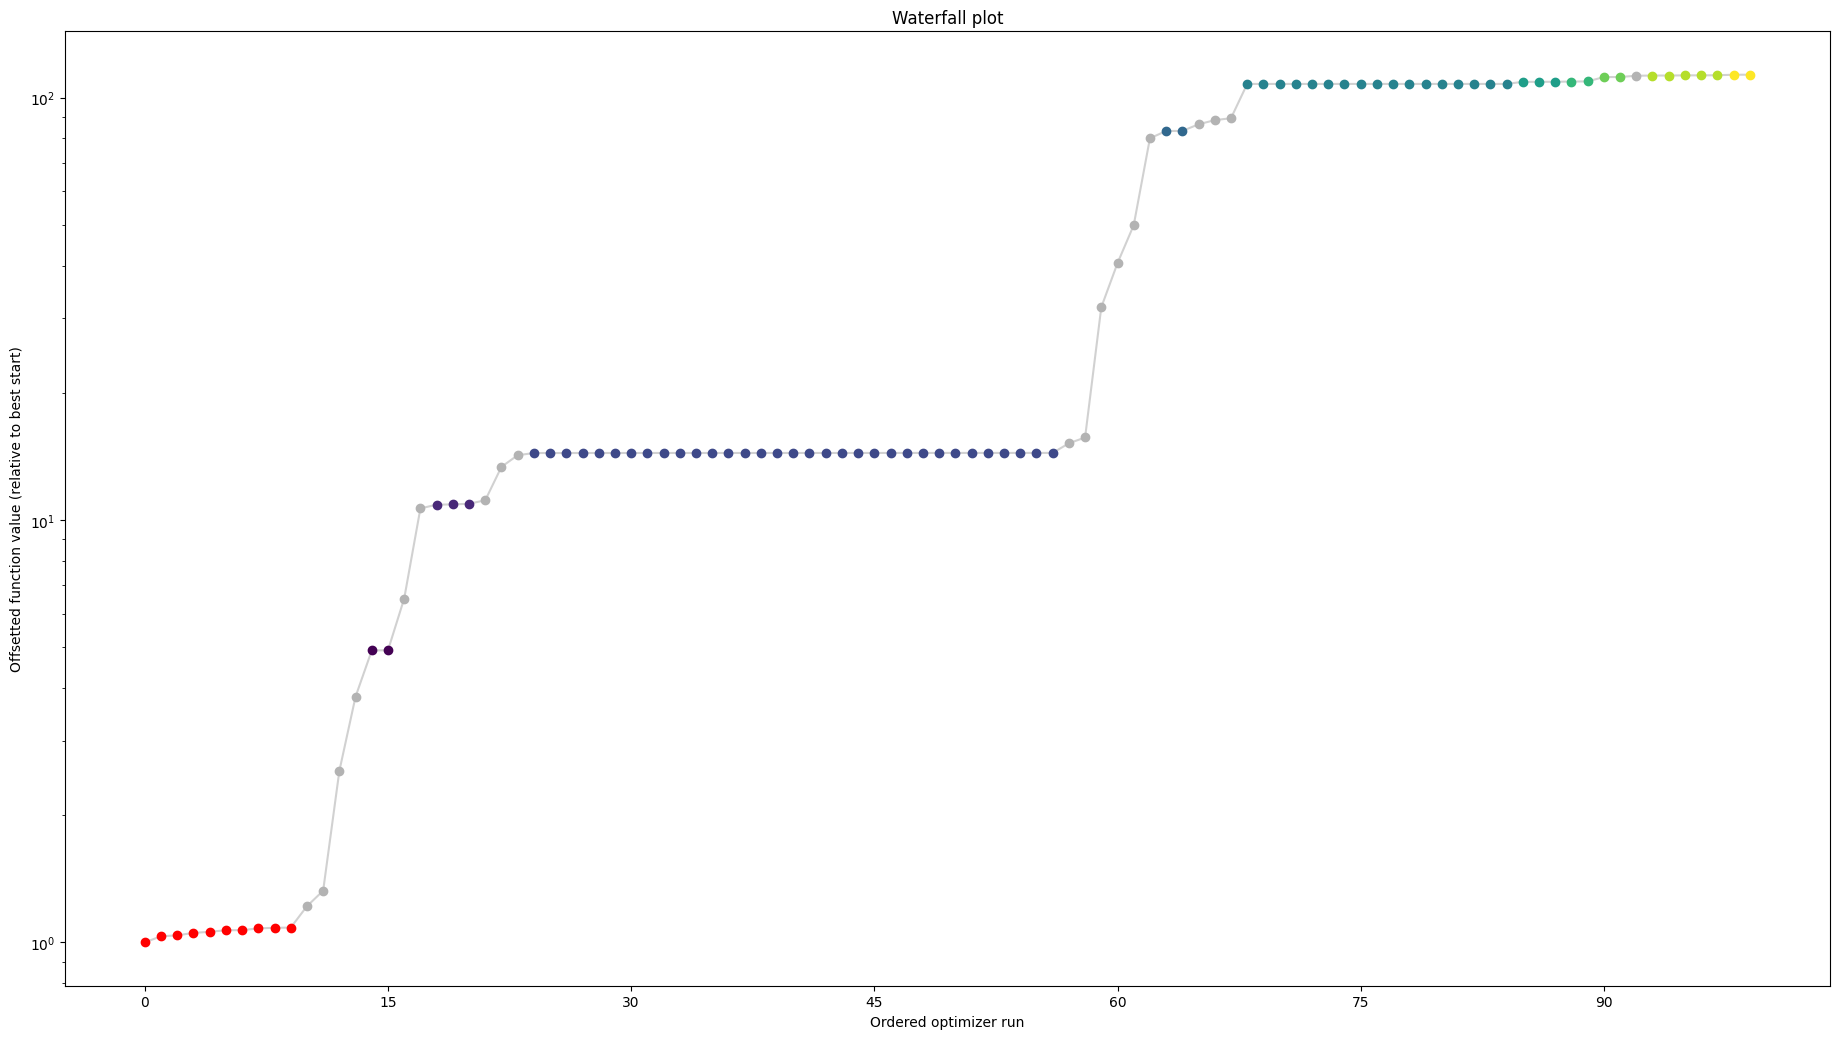

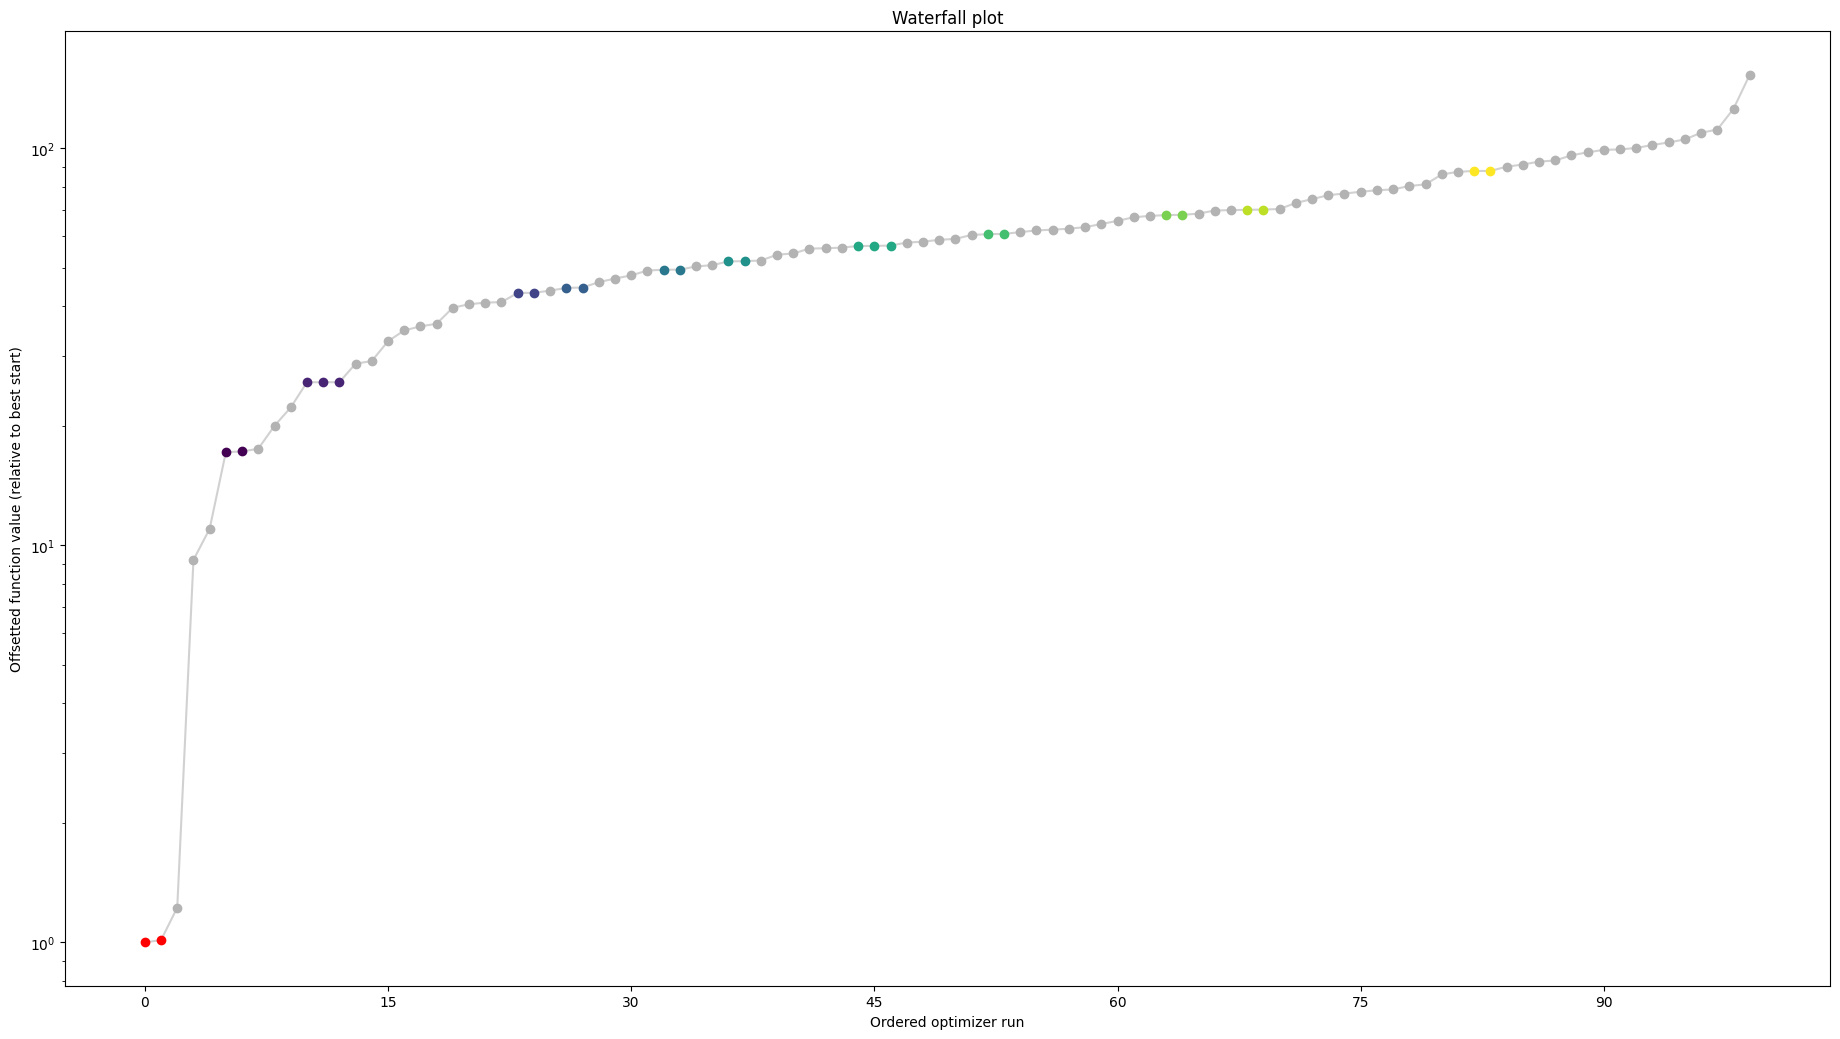

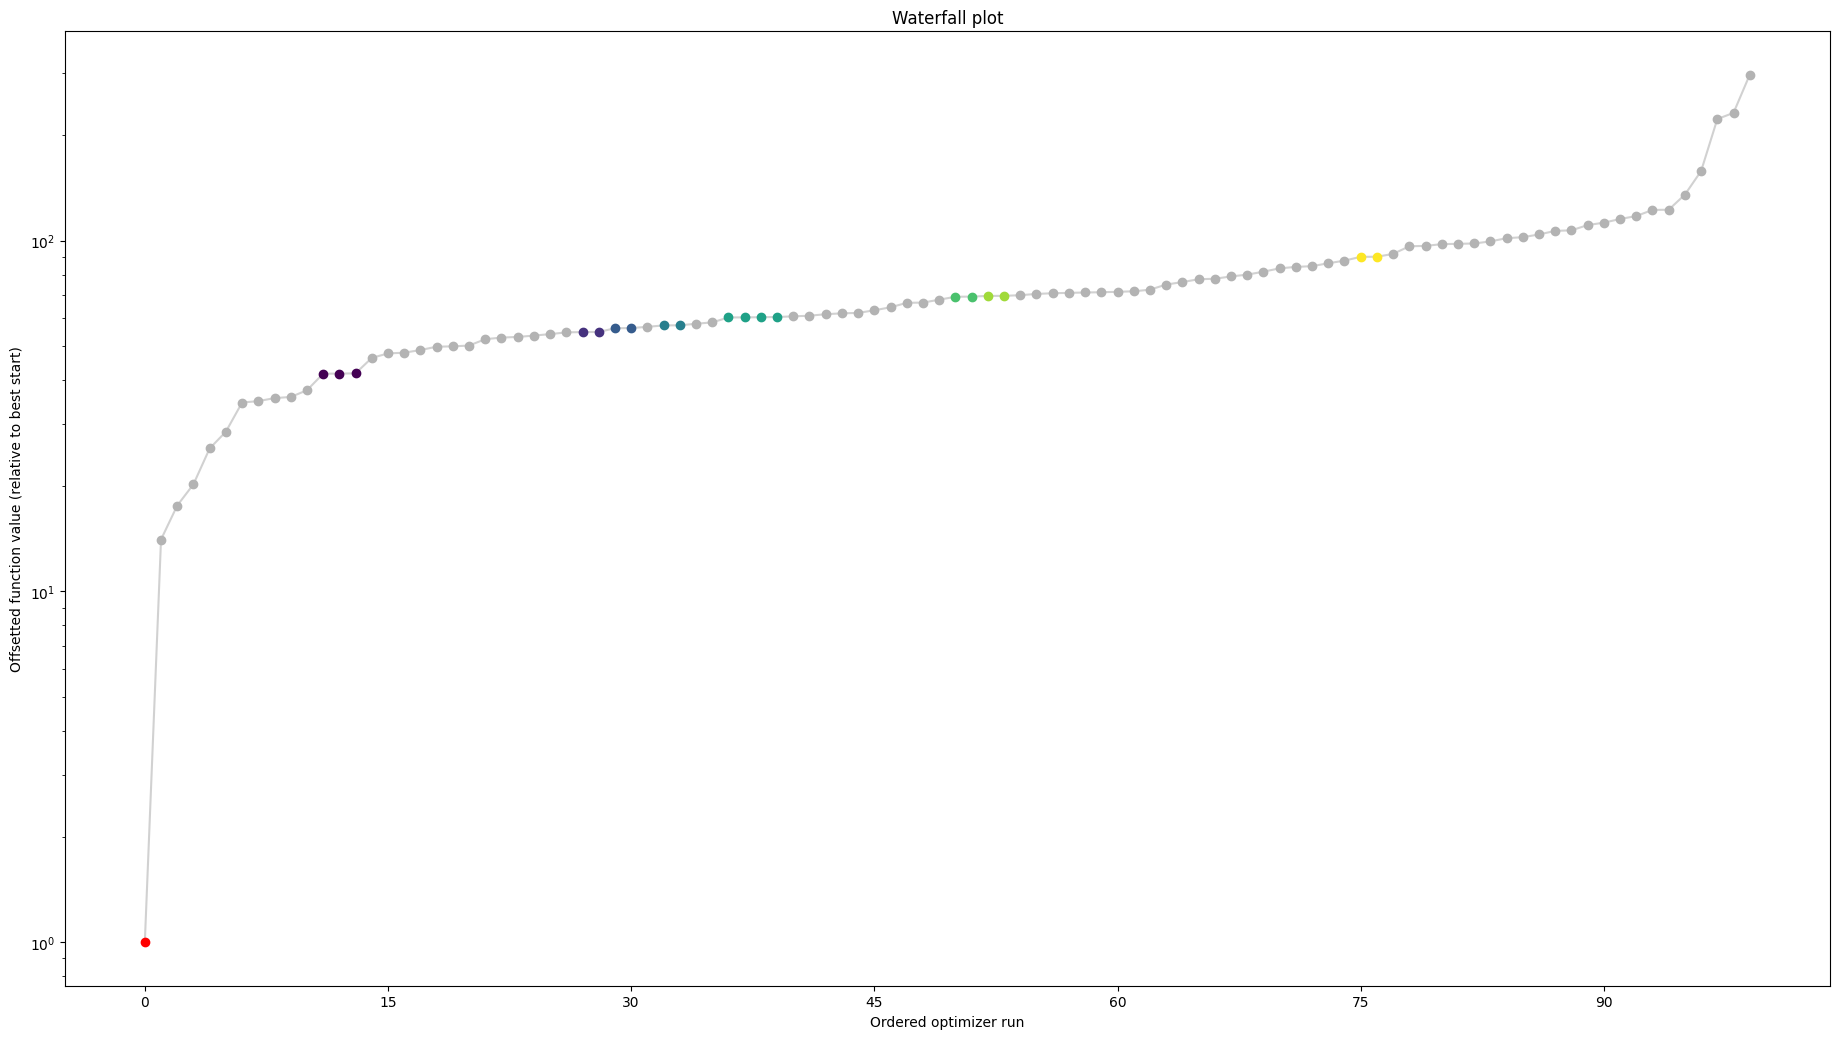

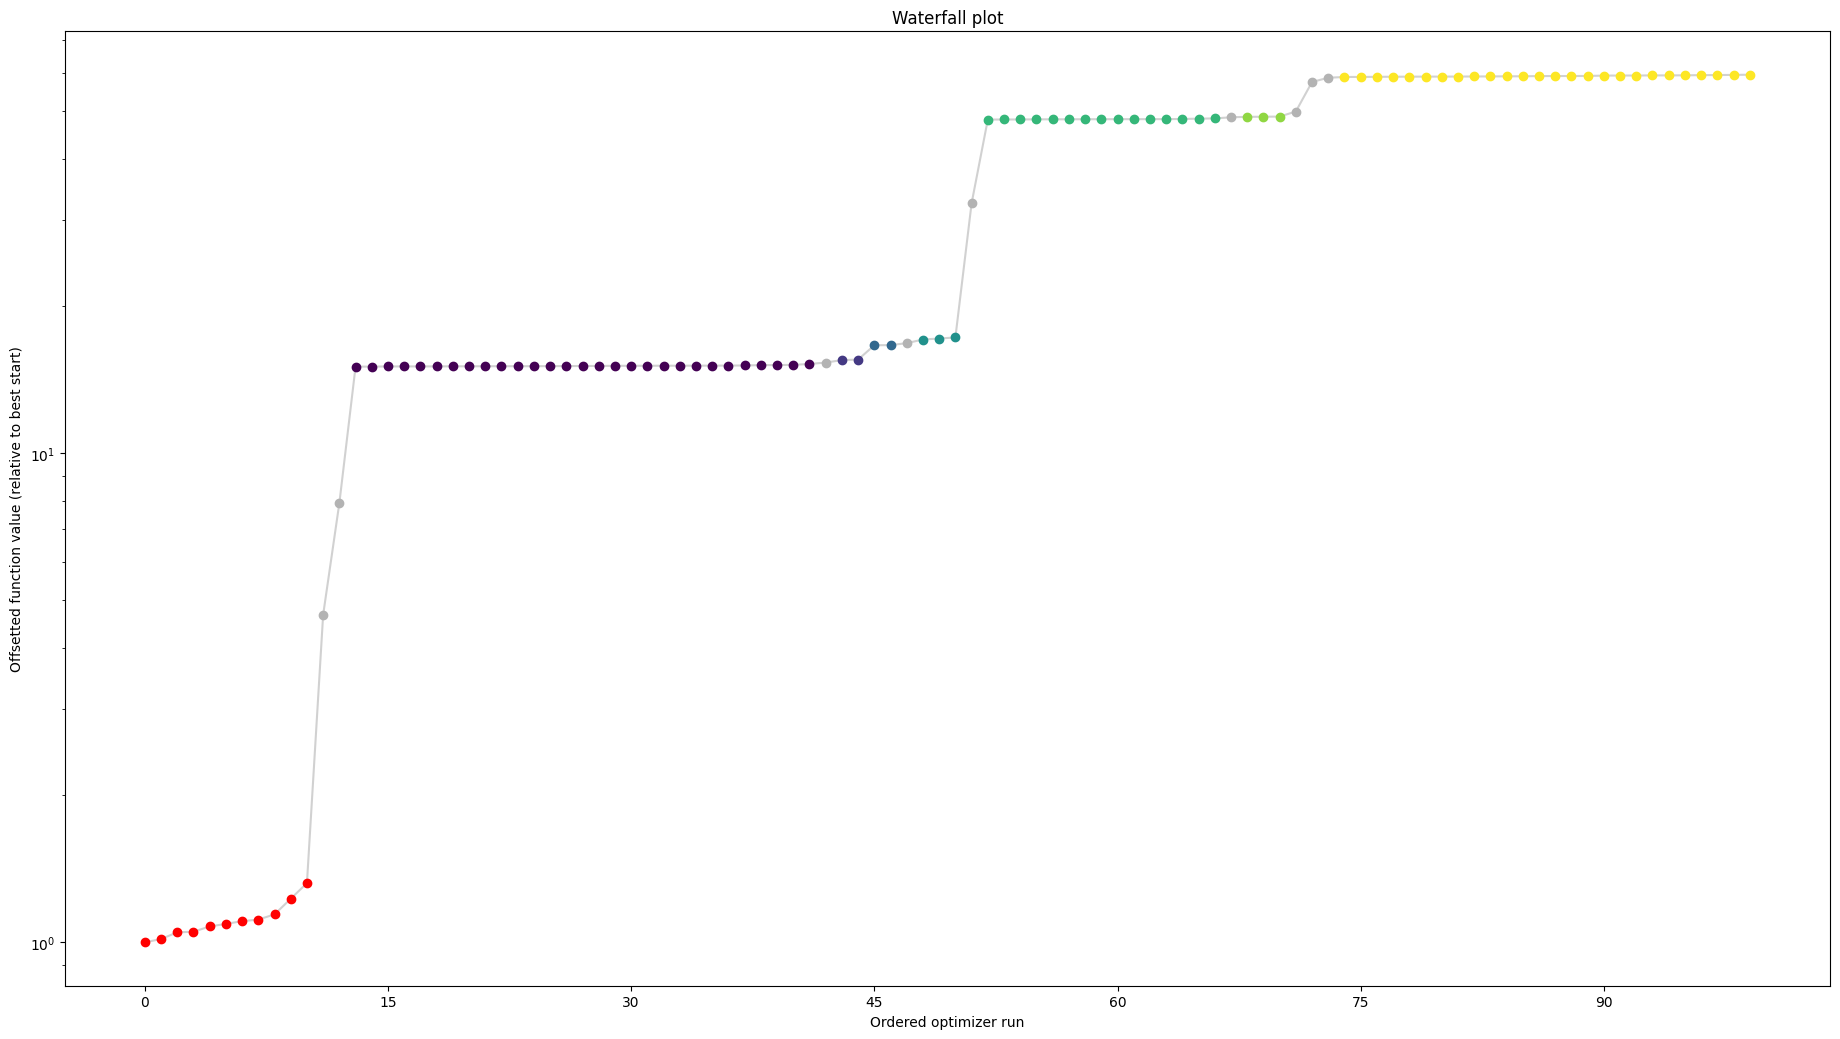

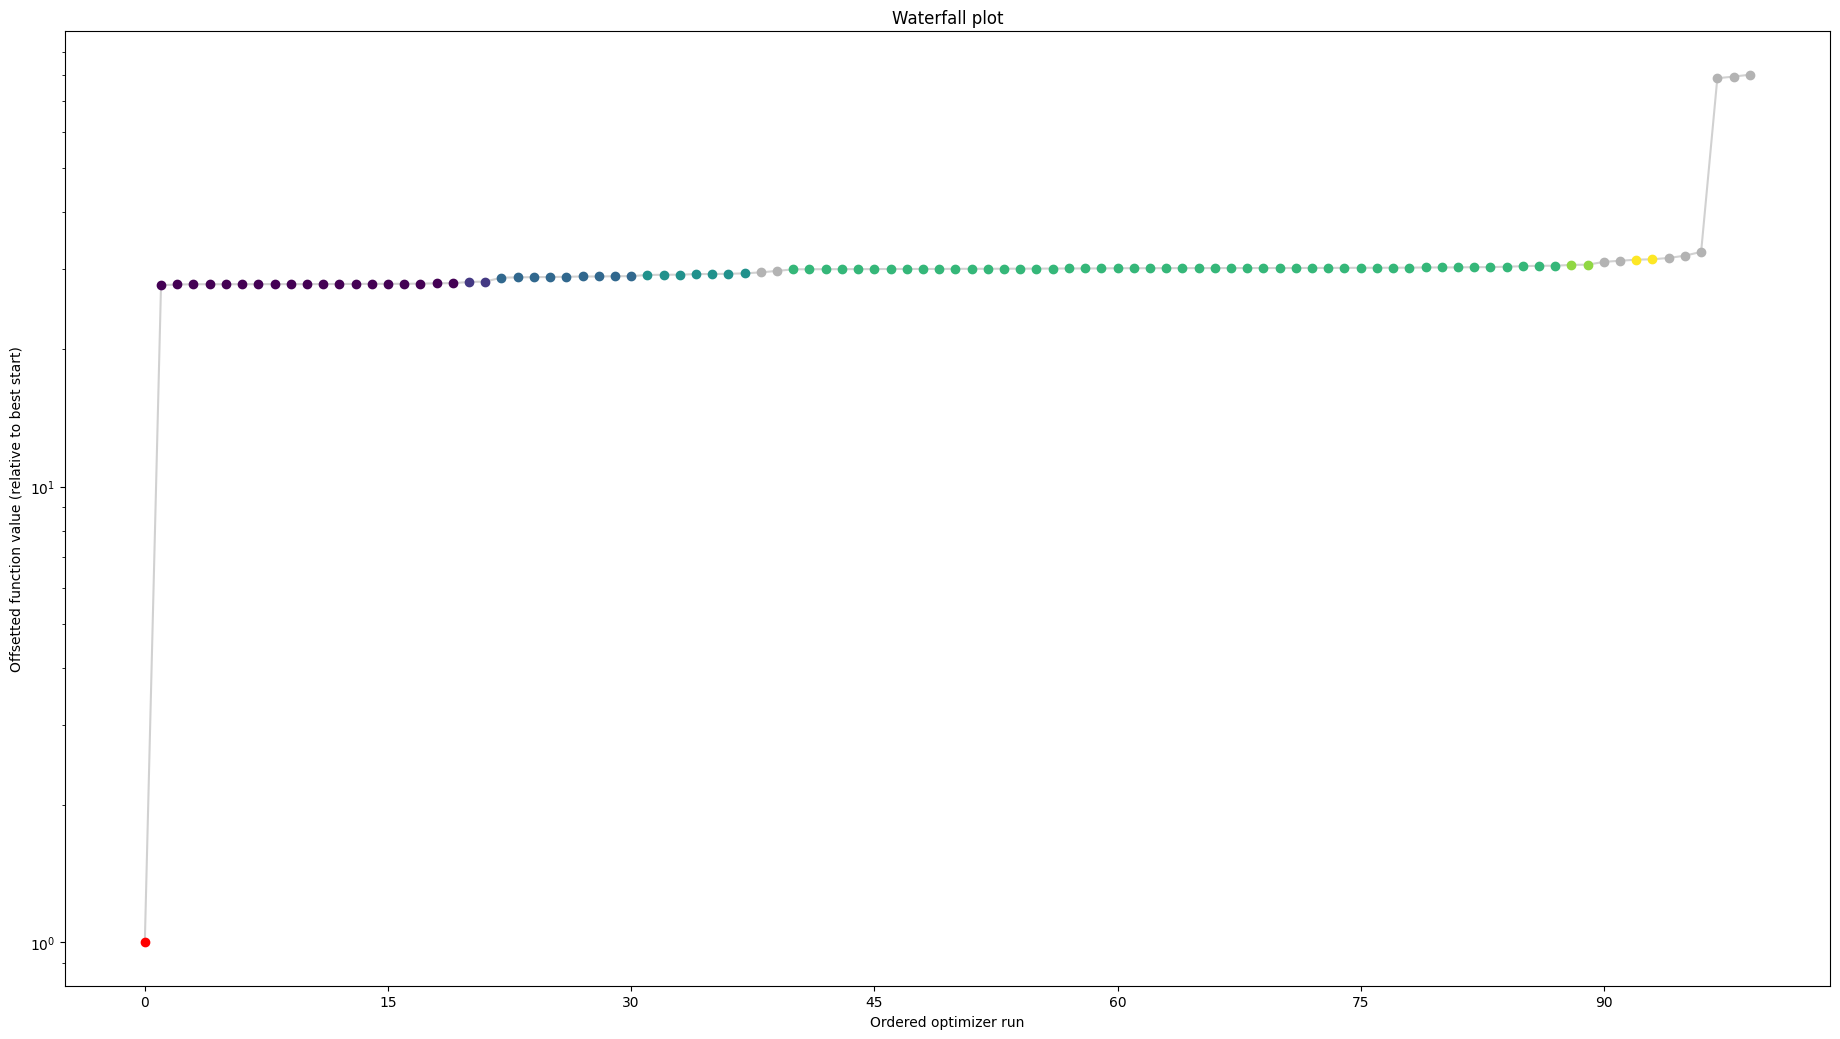

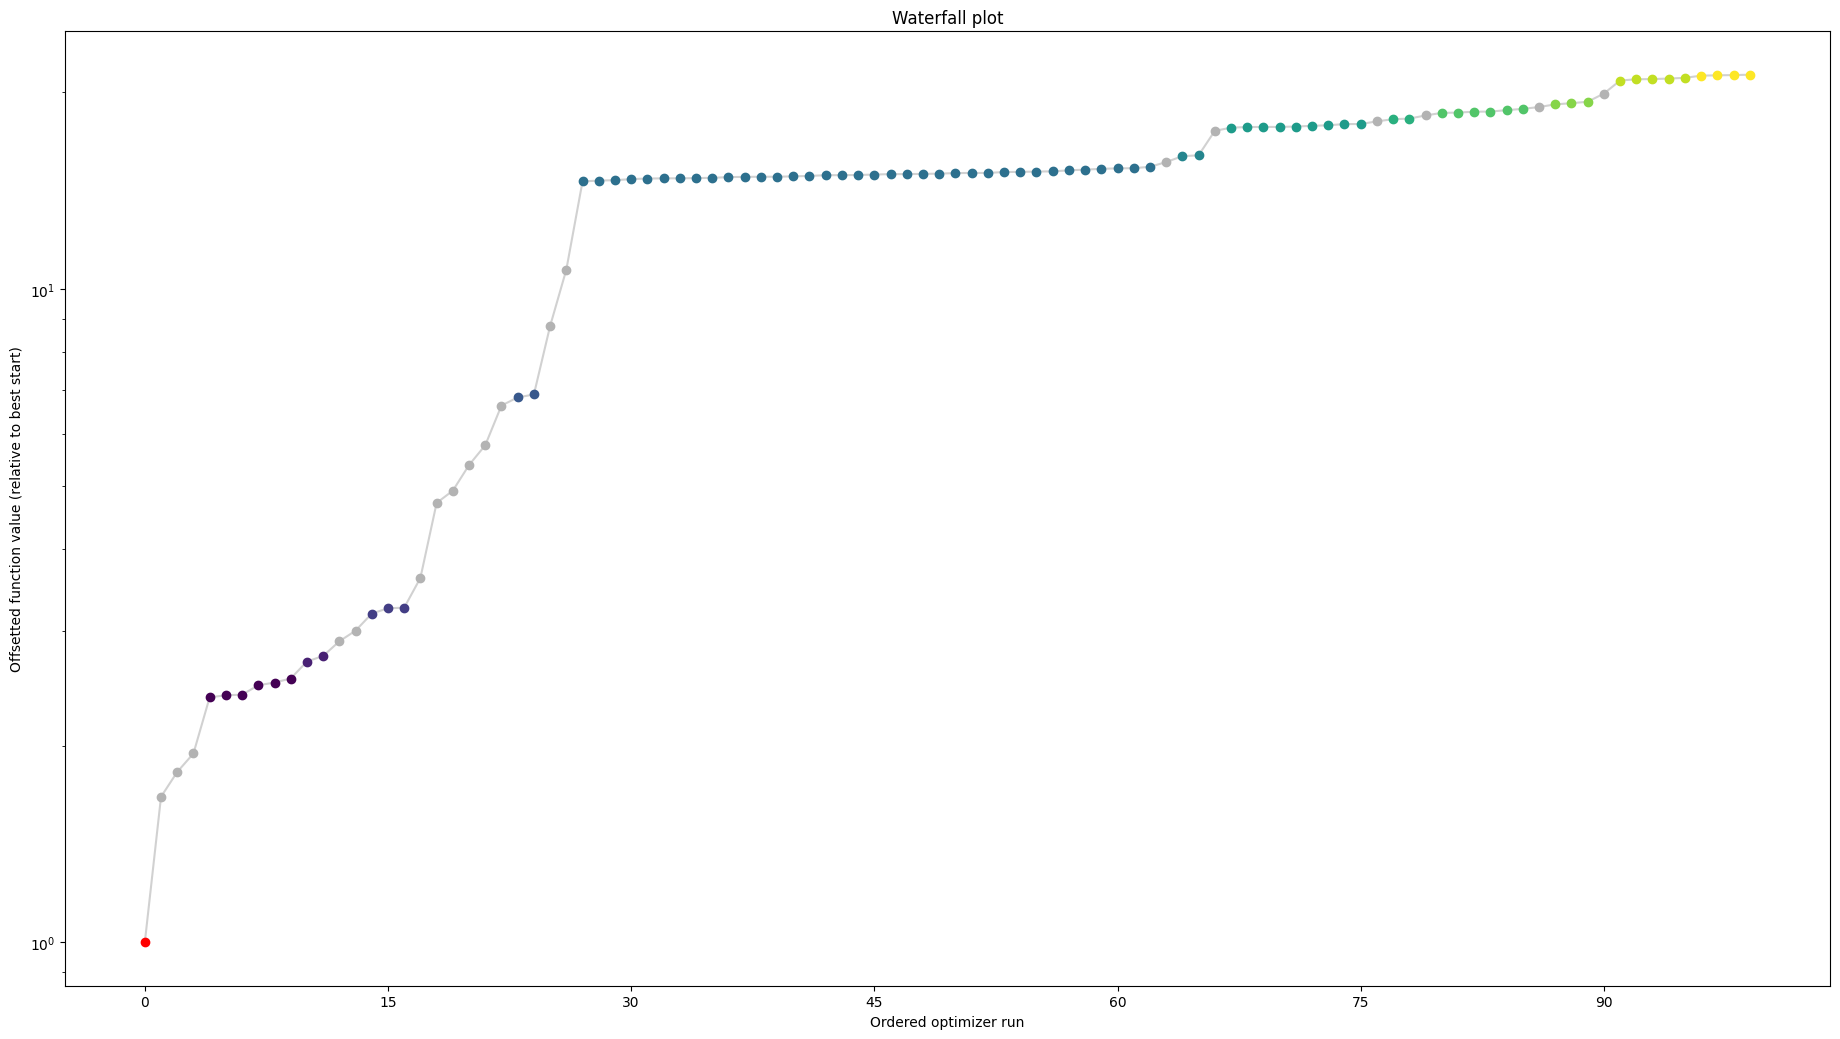

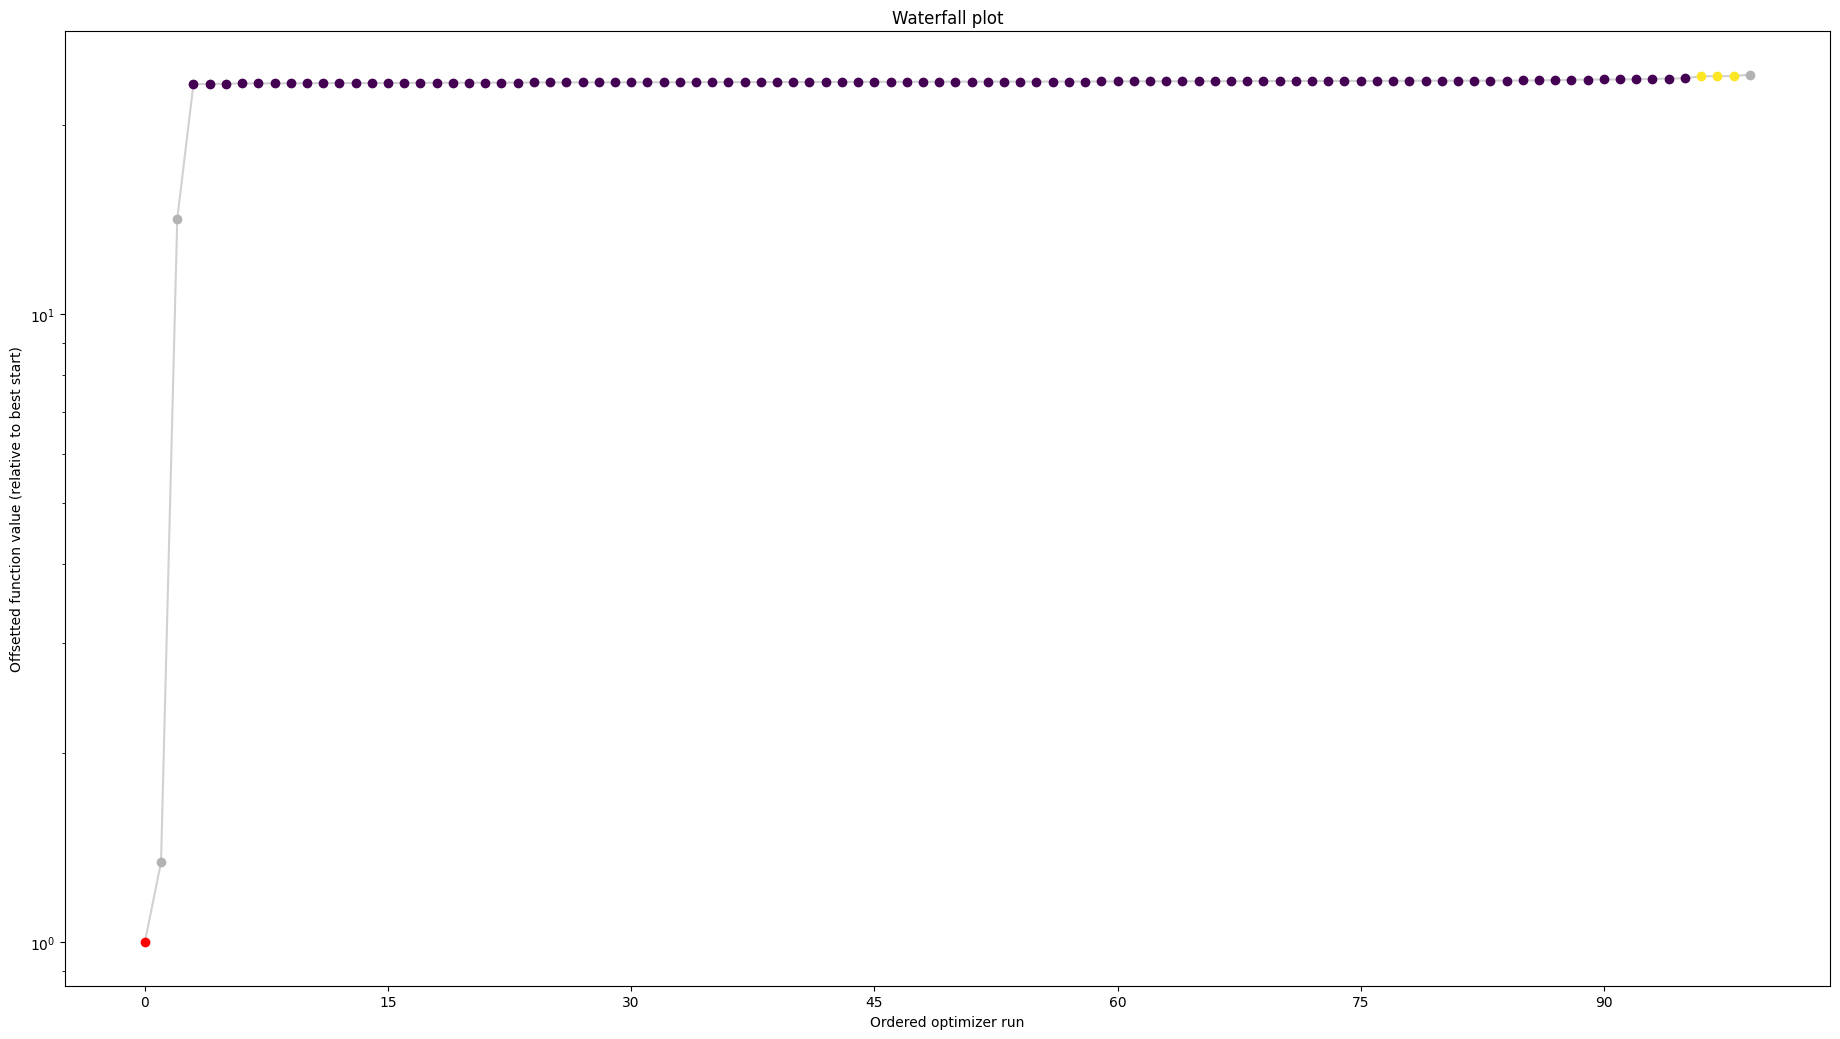

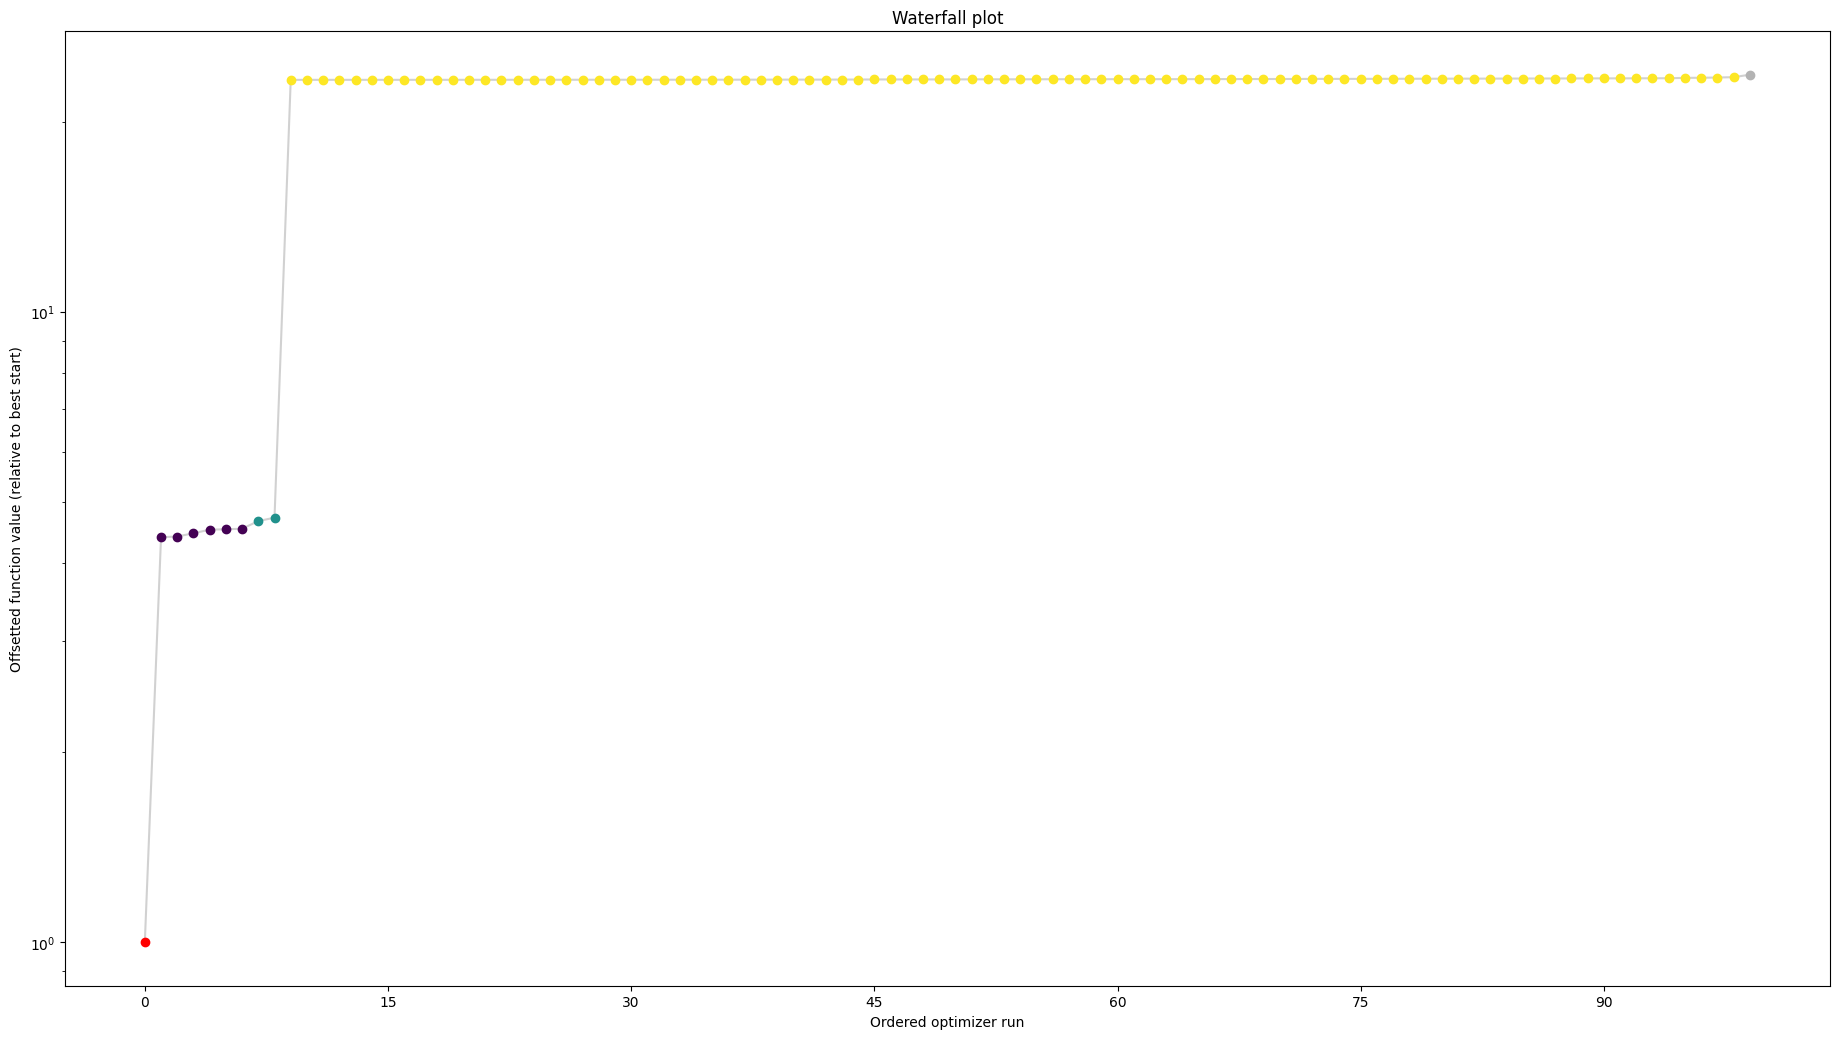

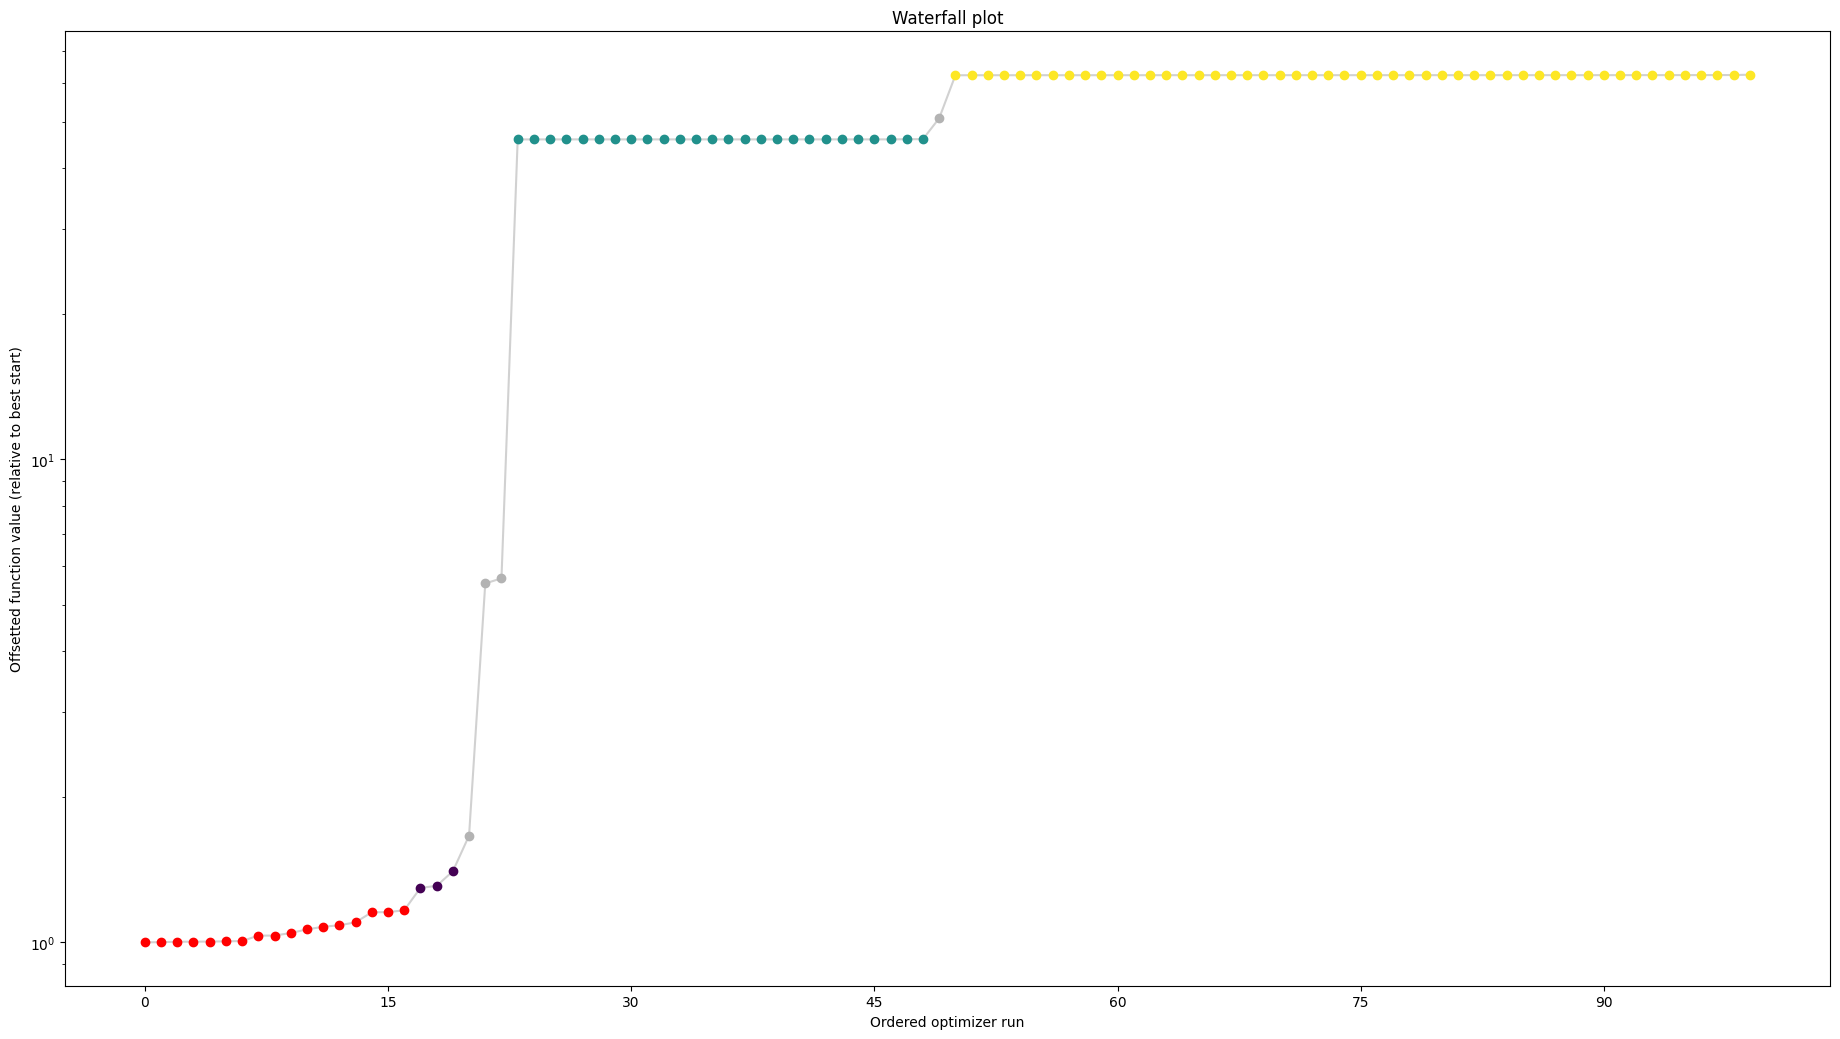

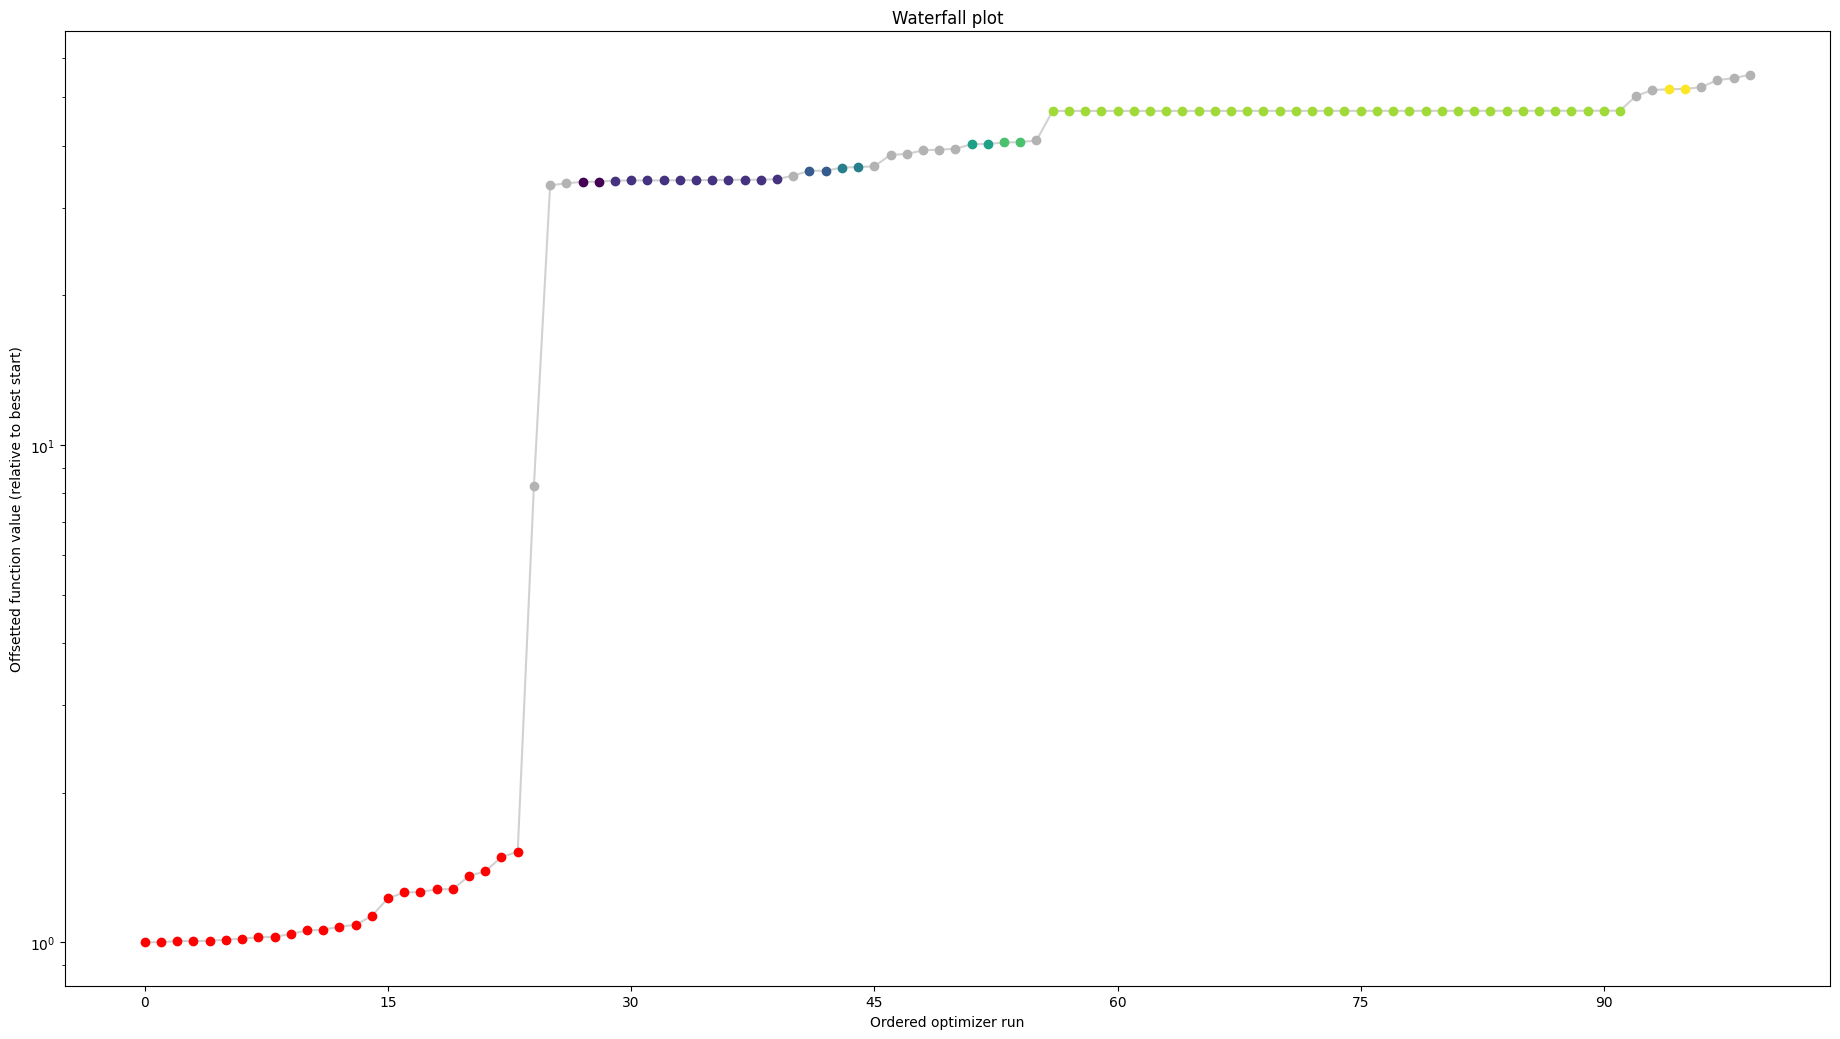

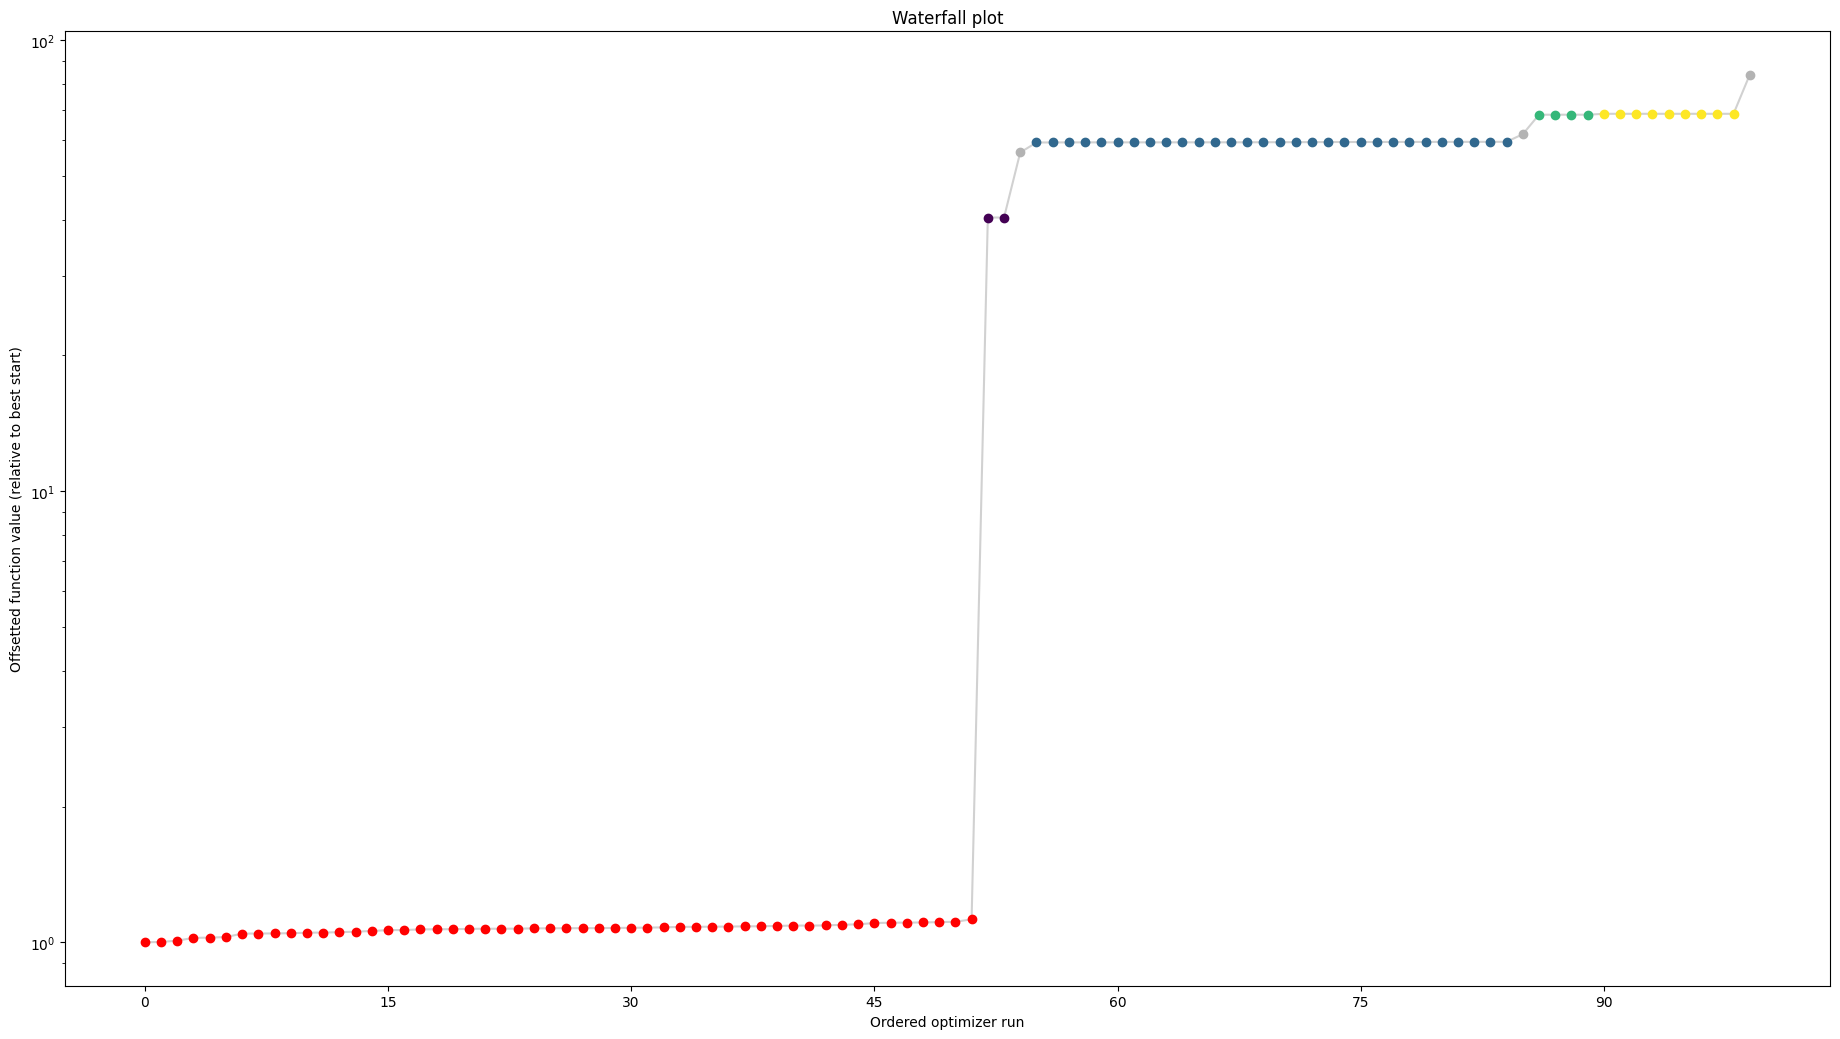

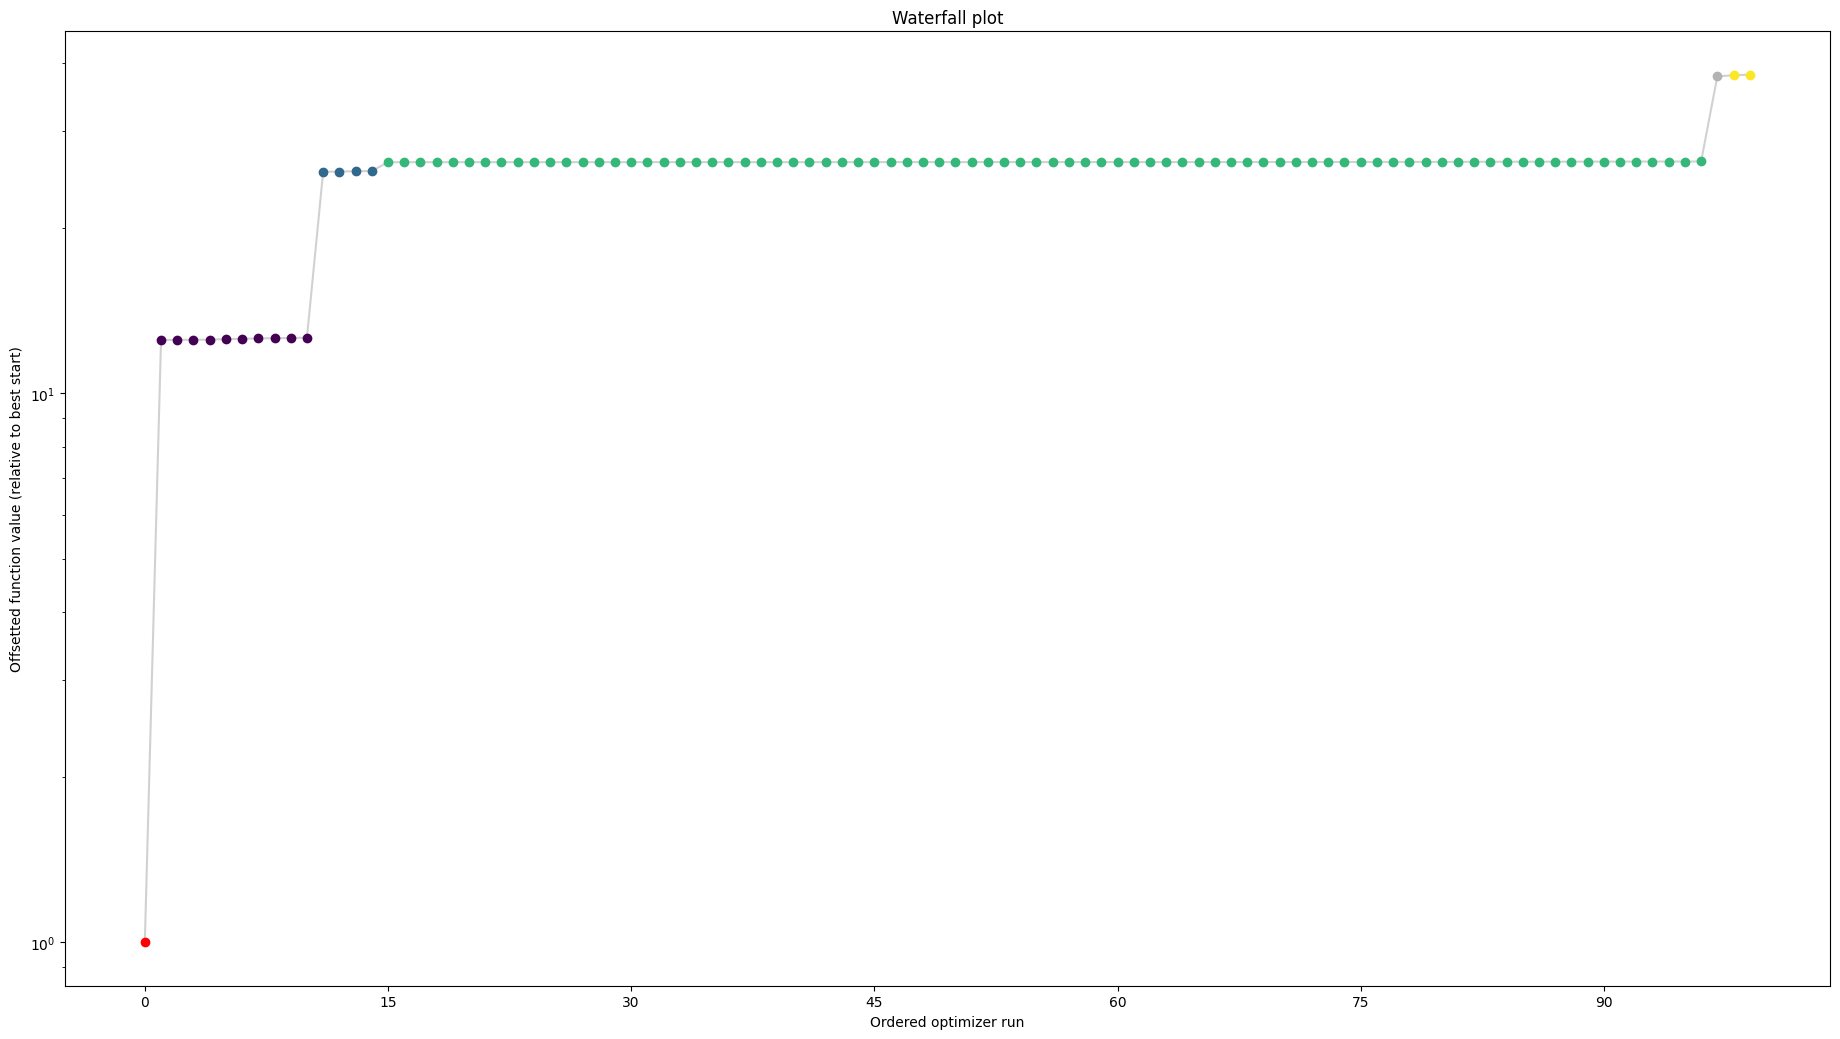

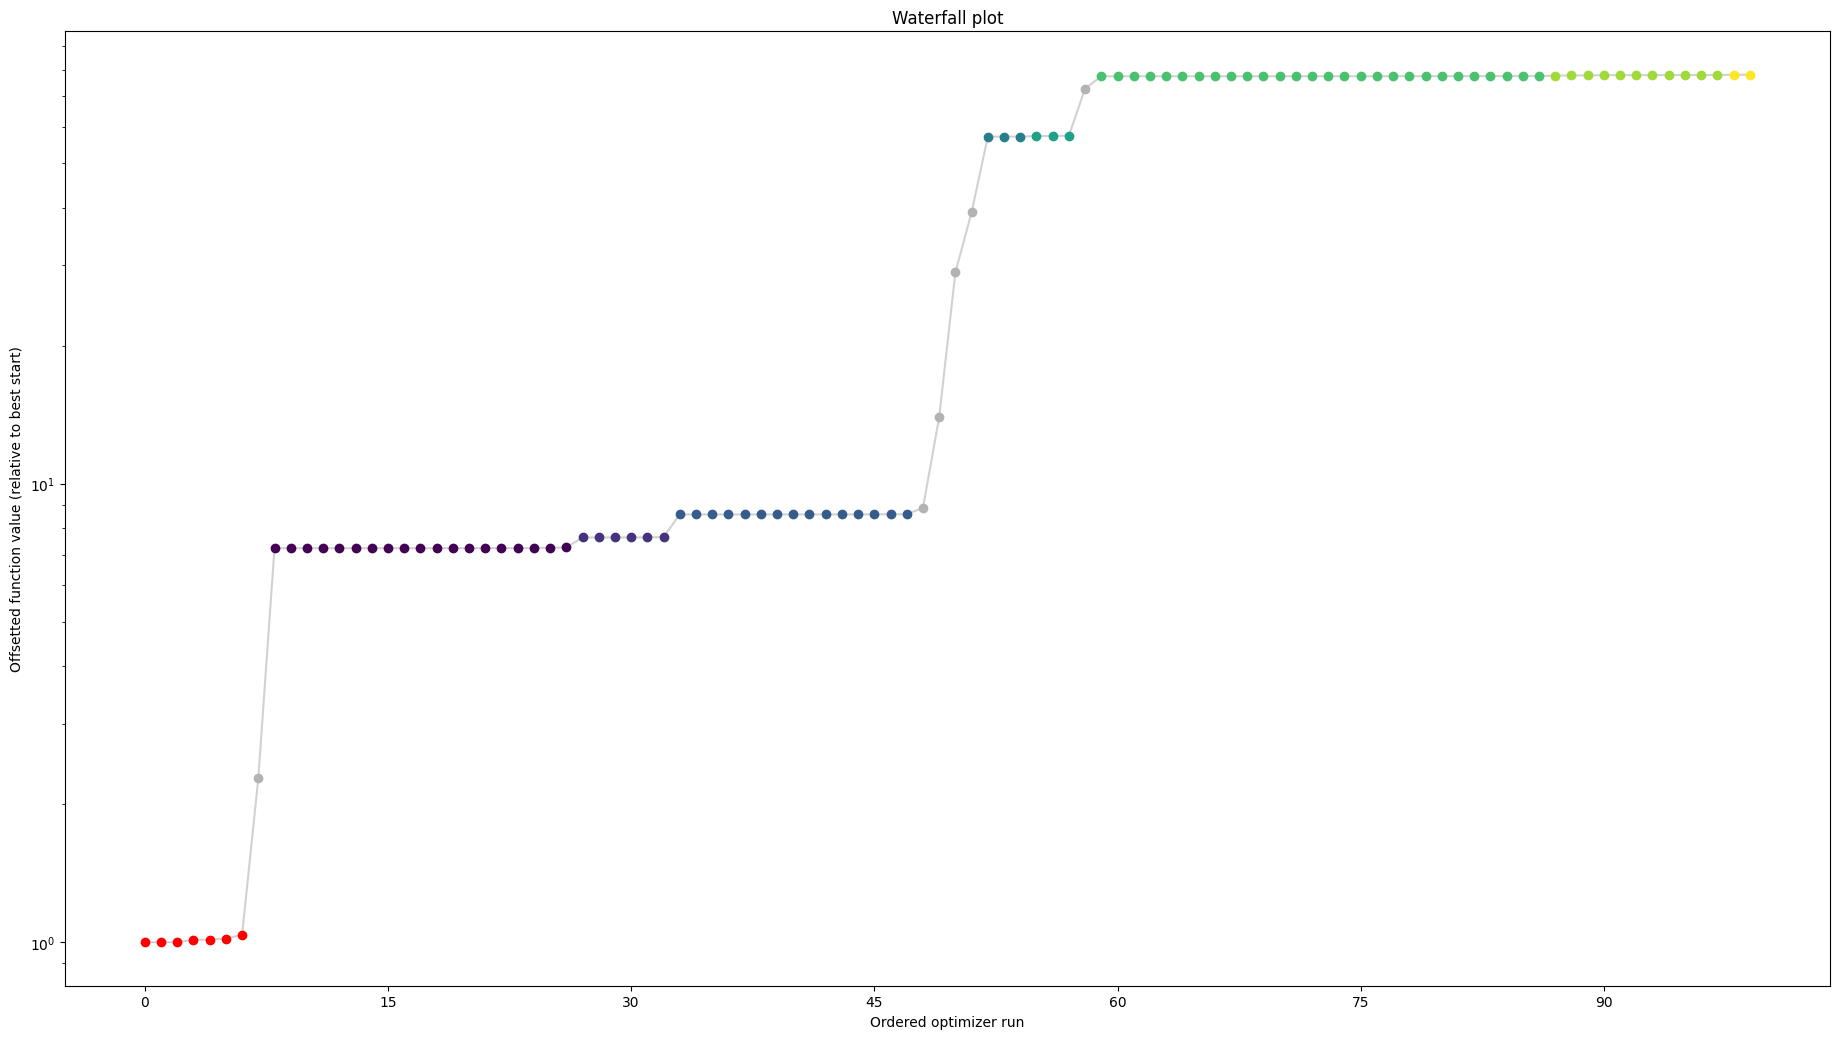

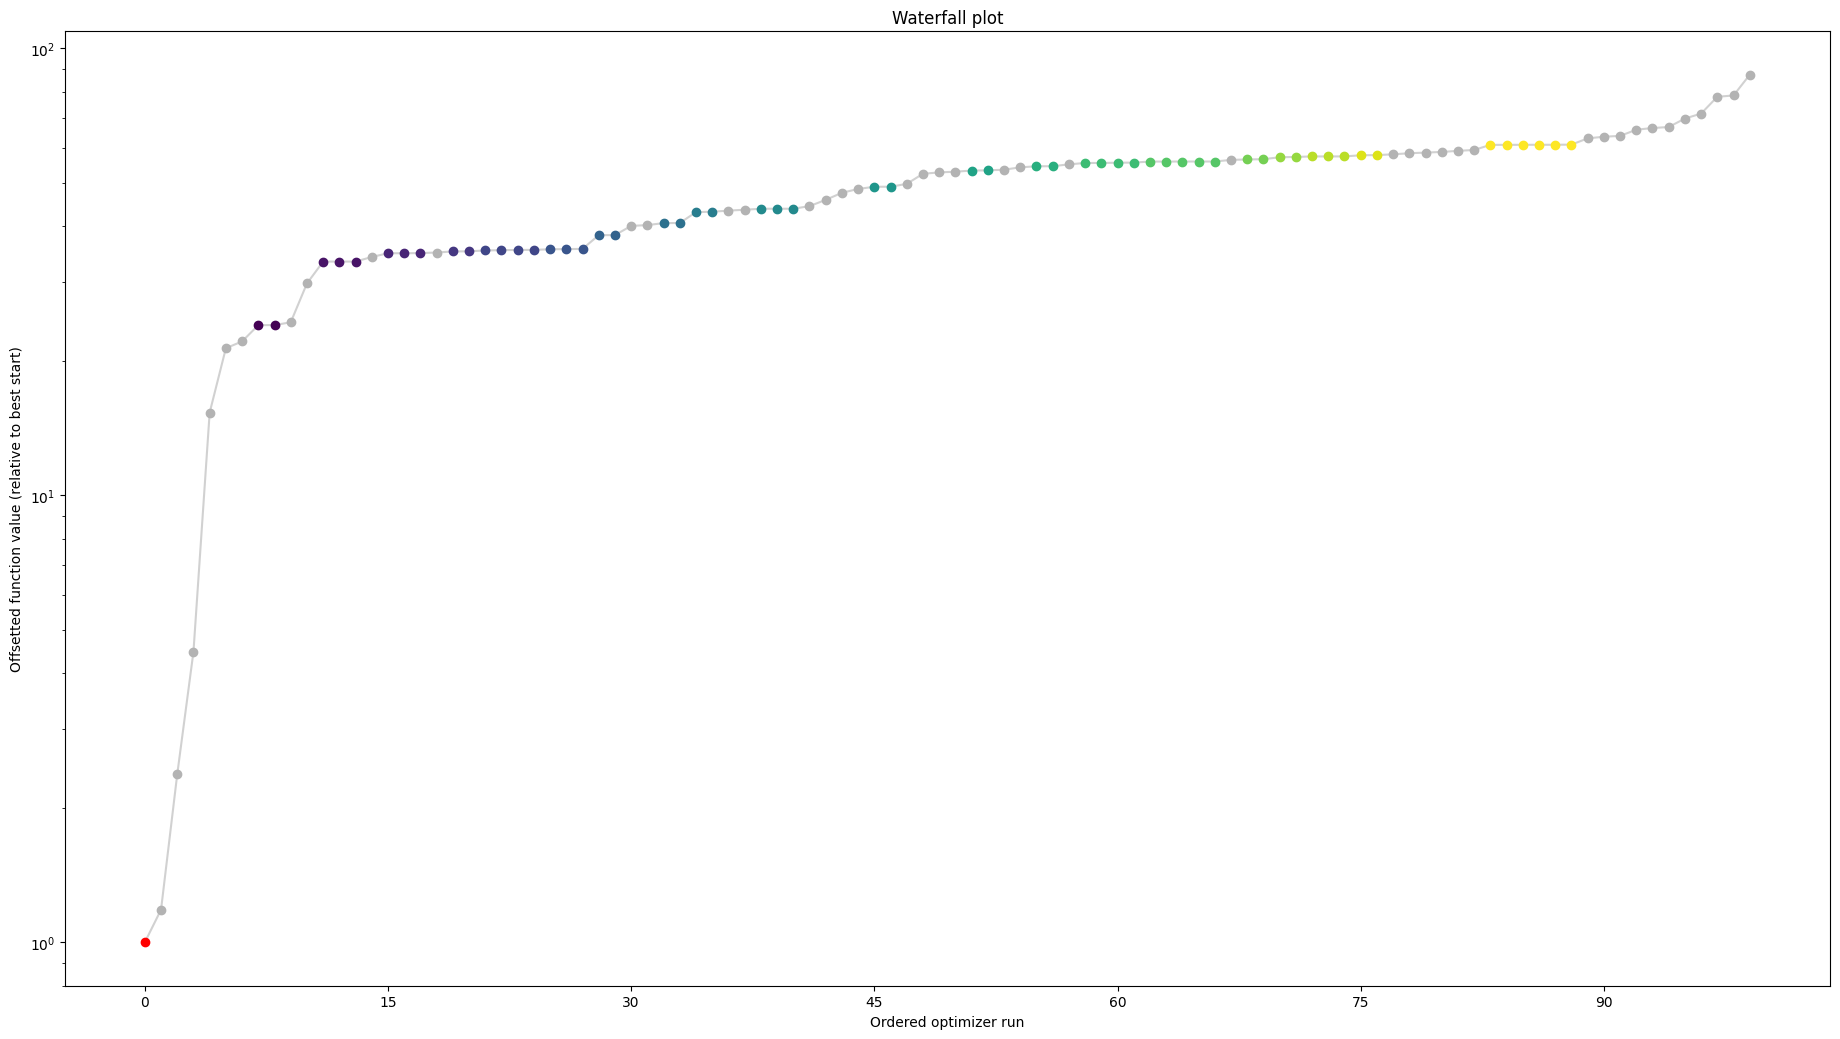

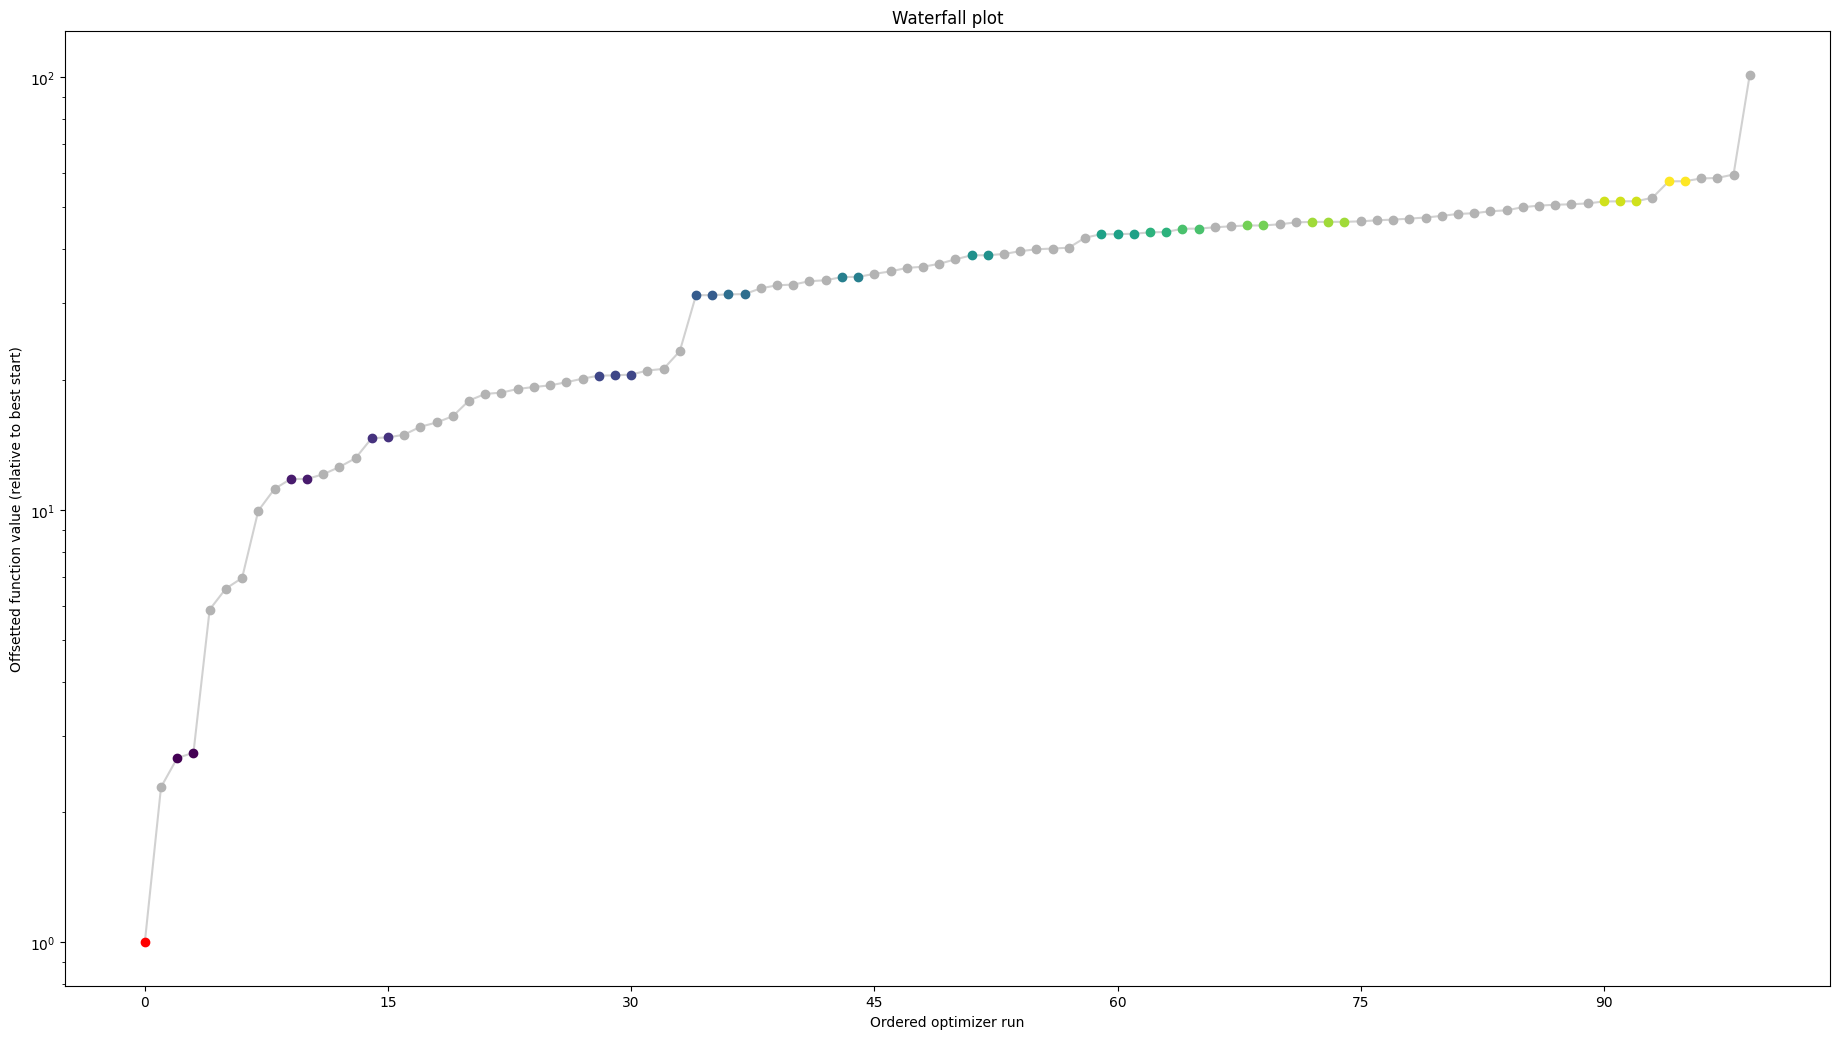

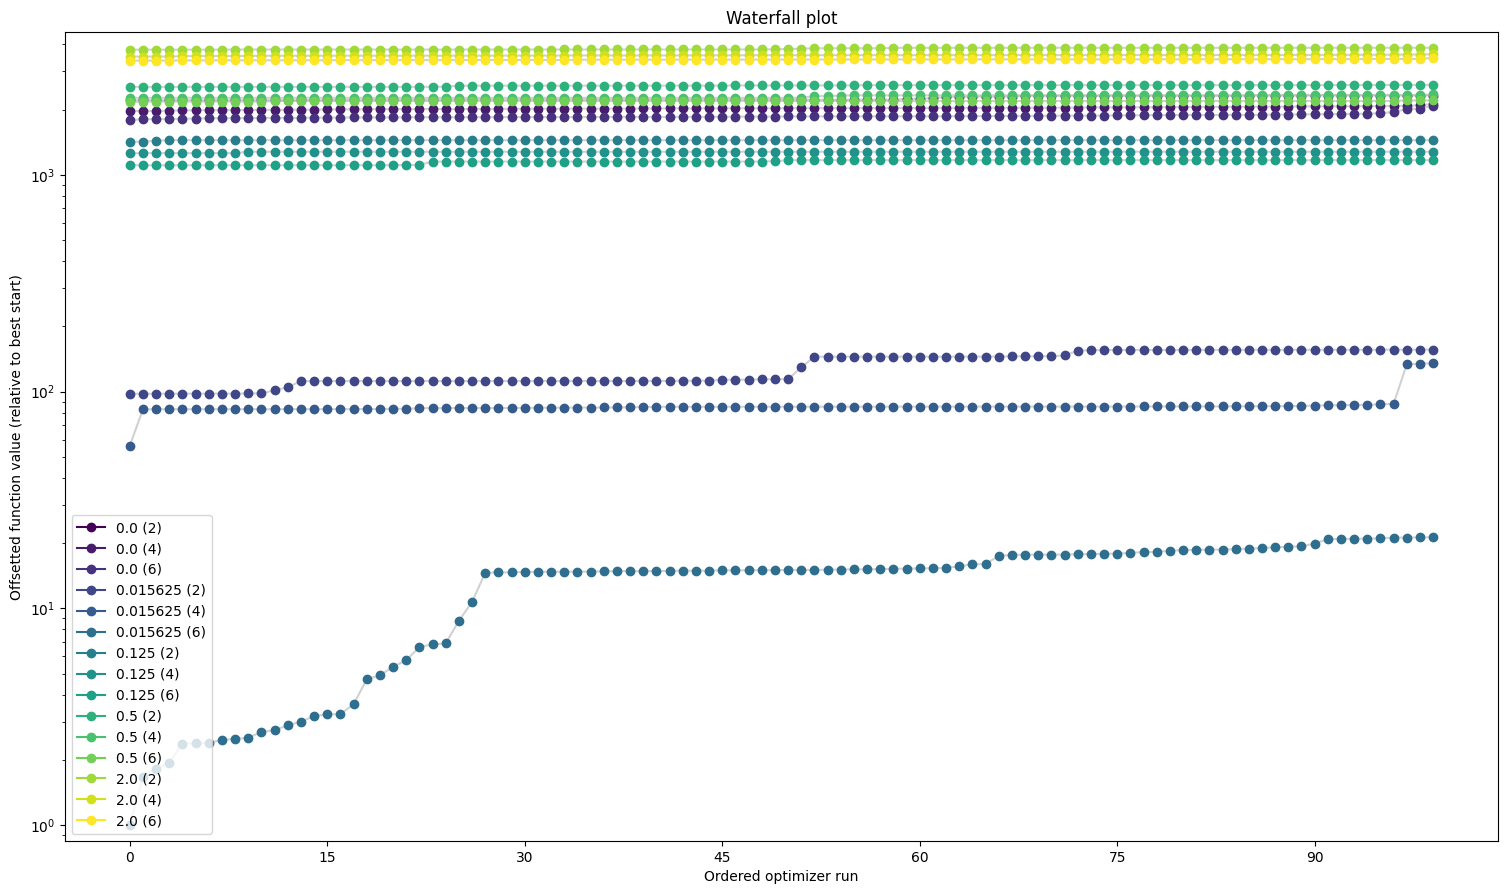

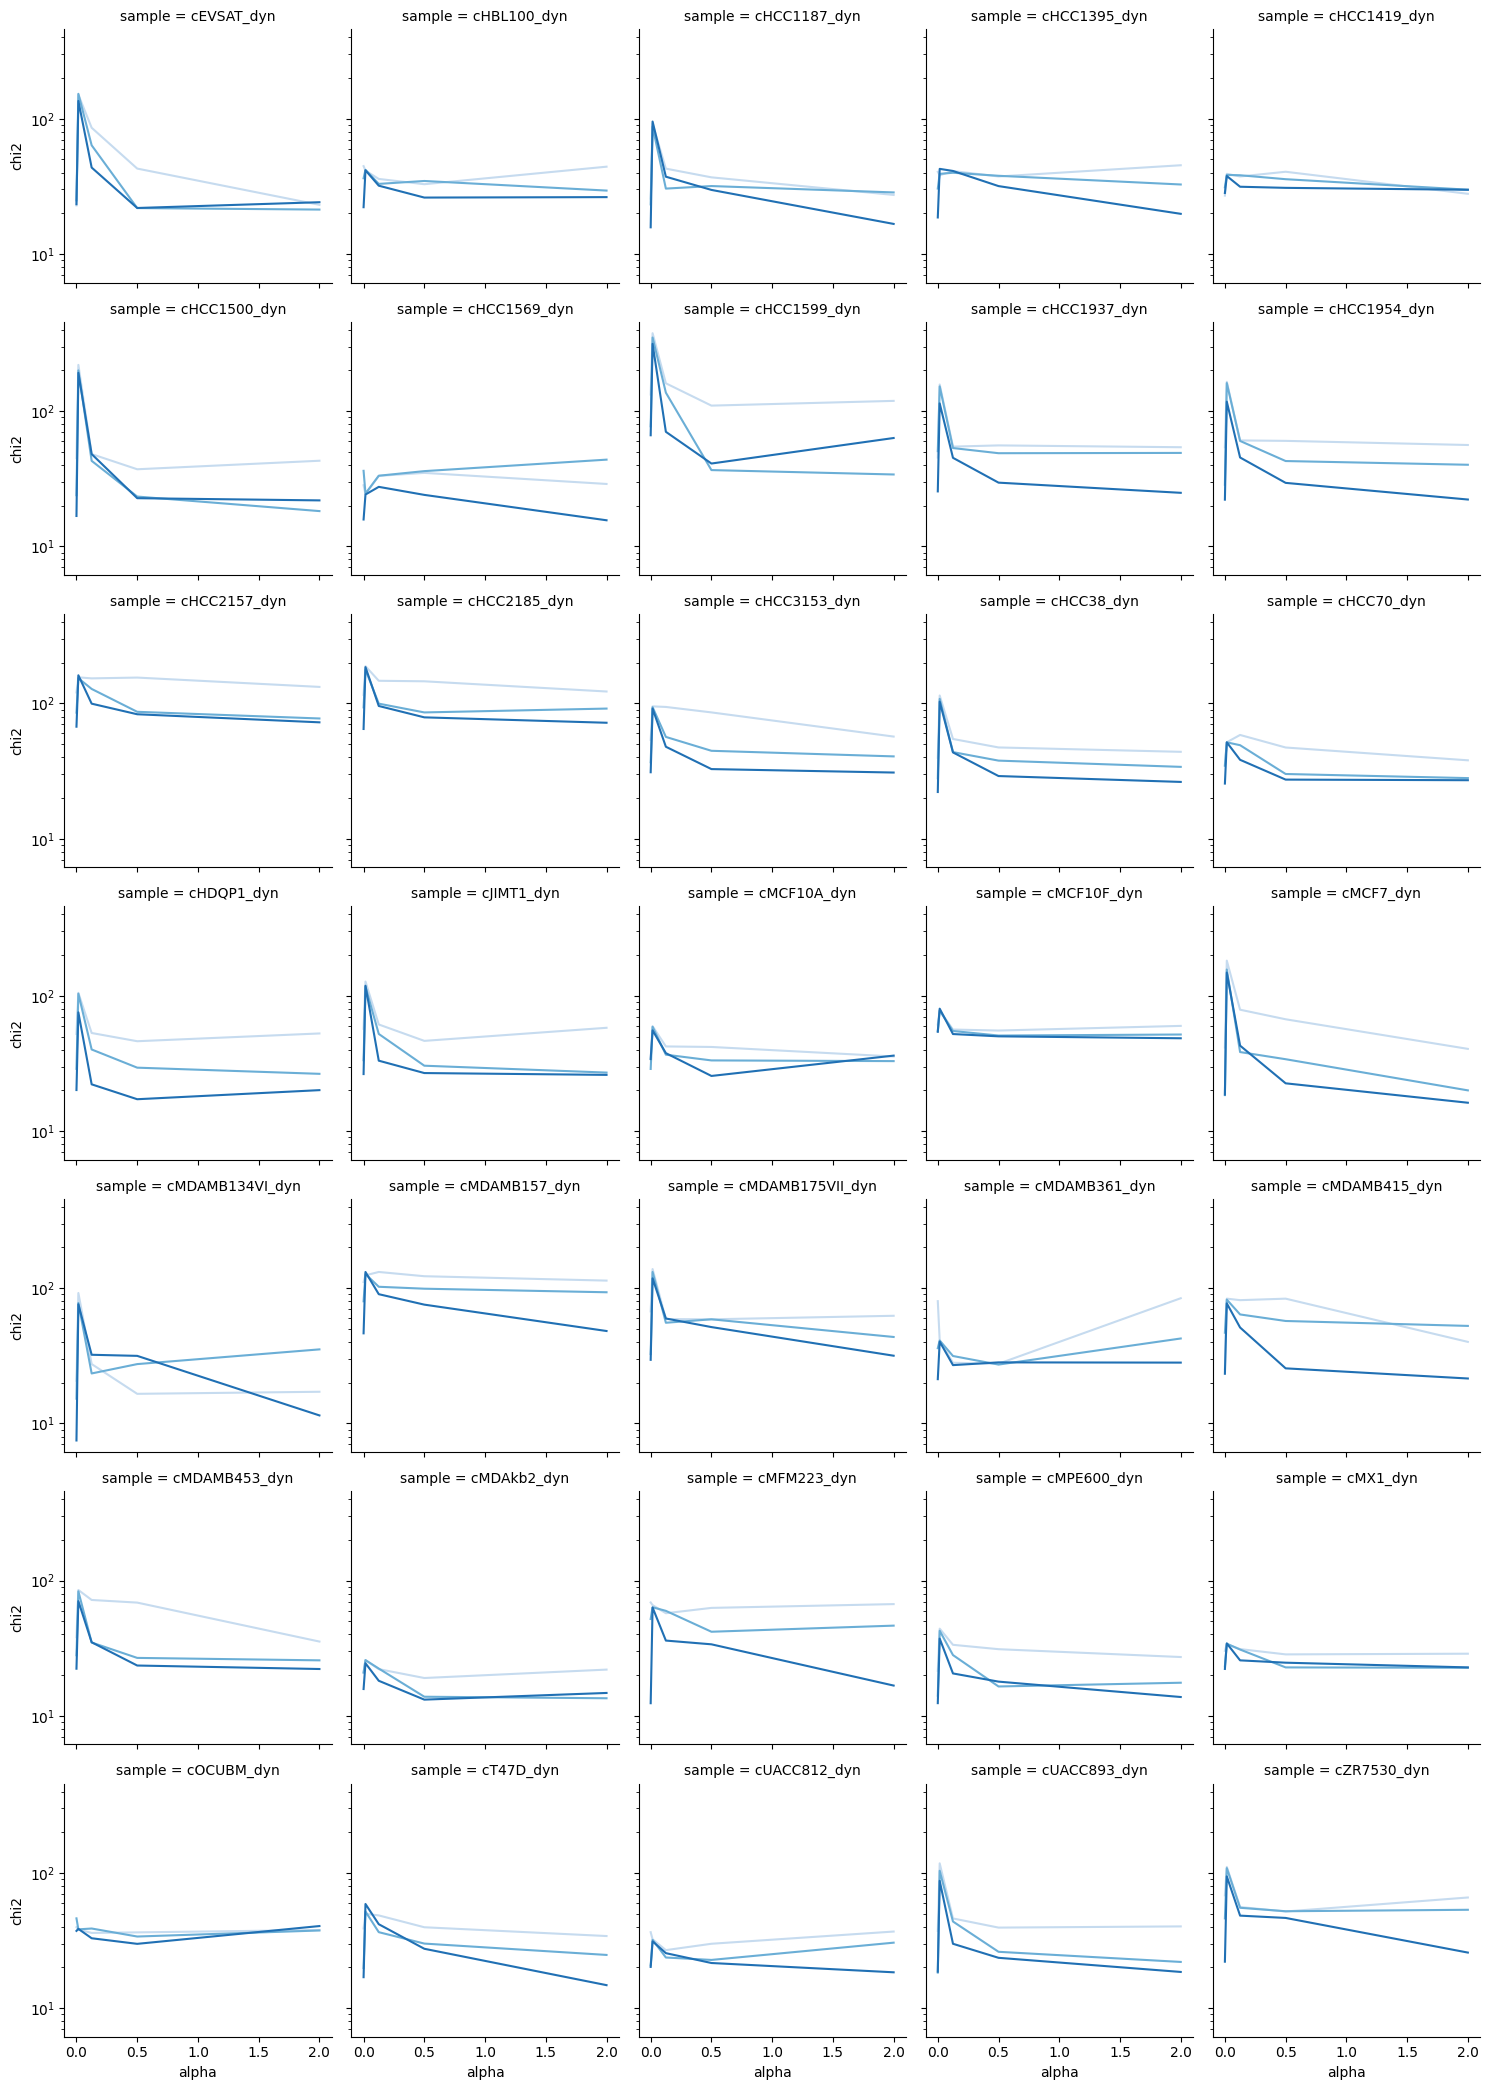

In [7]:
analyse("train")

Mismatch of noise parameter overrides in:
observableId                                              pERK_Y204_obs
preequilibrationConditionId                                      cEVSAT
time                                                                0.0
measurement                                                    1.652382
noiseParameters                                                0.734275
simulationConditionId                                       cEVSAT__EGF
observableParameters           pERK_Y204_obs_scale;pERK_Y204_obs_offset
Name: 25935, dtype: object
Expected 0 but got 1
Observable ID pERK_Y204_obs shadows model entity.
Observable ID pERBB2_Y1248_obs shadows model entity.
Observable ID pMEK_S222_obs shadows model entity.
Observable ID pRPS6KA1_S380_obs shadows model entity.
Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/amici_models/EGFR_MAPK_dream_cytof__EGFR_MAPK_petab.
Mismatch of noise parameter overrides in:
observableId                    

Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/amici_models/EGFR_MAPK_dream_cytof__EGFR_MAPK_petab.
Mismatch of noise parameter overrides in:
observableId                                              pERK_Y204_obs
preequilibrationConditionId                                      c184A1
time                                                                0.0
measurement                                                    2.651779
noiseParameters                                                 0.86554
simulationConditionId                                       c184A1__EGF
observableParameters           pERK_Y204_obs_scale;pERK_Y204_obs_offset
Name: 25524, dtype: object
Expected 0 but got 1
Observable ID pERK_Y204_obs shadows model entity.
Observable ID pERBB2_Y1248_obs shadows model entity.
Observable ID pMEK_S222_obs shadows model entity.
Observable ID pRPS6KA1_S380_obs shadows model entity.
Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/am

Observable ID pMEK_S222_obs shadows model entity.
Observable ID pRPS6KA1_S380_obs shadows model entity.
Not OK
Using existing amici model in folder /home/ff72/mechanismEncoder/amici_models/EGFR_MAPK_dream_cytof__EGFR_MAPK_petab.
Mismatch of noise parameter overrides in:
observableId                                              pERK_Y204_obs
preequilibrationConditionId                                      cEVSAT
time                                                                0.0
measurement                                                    1.652382
noiseParameters                                                0.734275
simulationConditionId                                       cEVSAT__EGF
observableParameters           pERK_Y204_obs_scale;pERK_Y204_obs_offset
Name: 25935, dtype: object
Expected 0 but got 1
Observable ID pERK_Y204_obs shadows model entity.
Observable ID pERBB2_Y1248_obs shadows model entity.
Observable ID pMEK_S222_obs shadows model entity.
Observable ID pRPS6KA1_S

FileNotFoundError: [Errno 2] No such file or directory: '/home/ff72/mechanismEncoder/data/dream_cytof__EGFR_MAPK__measurements.tsv'

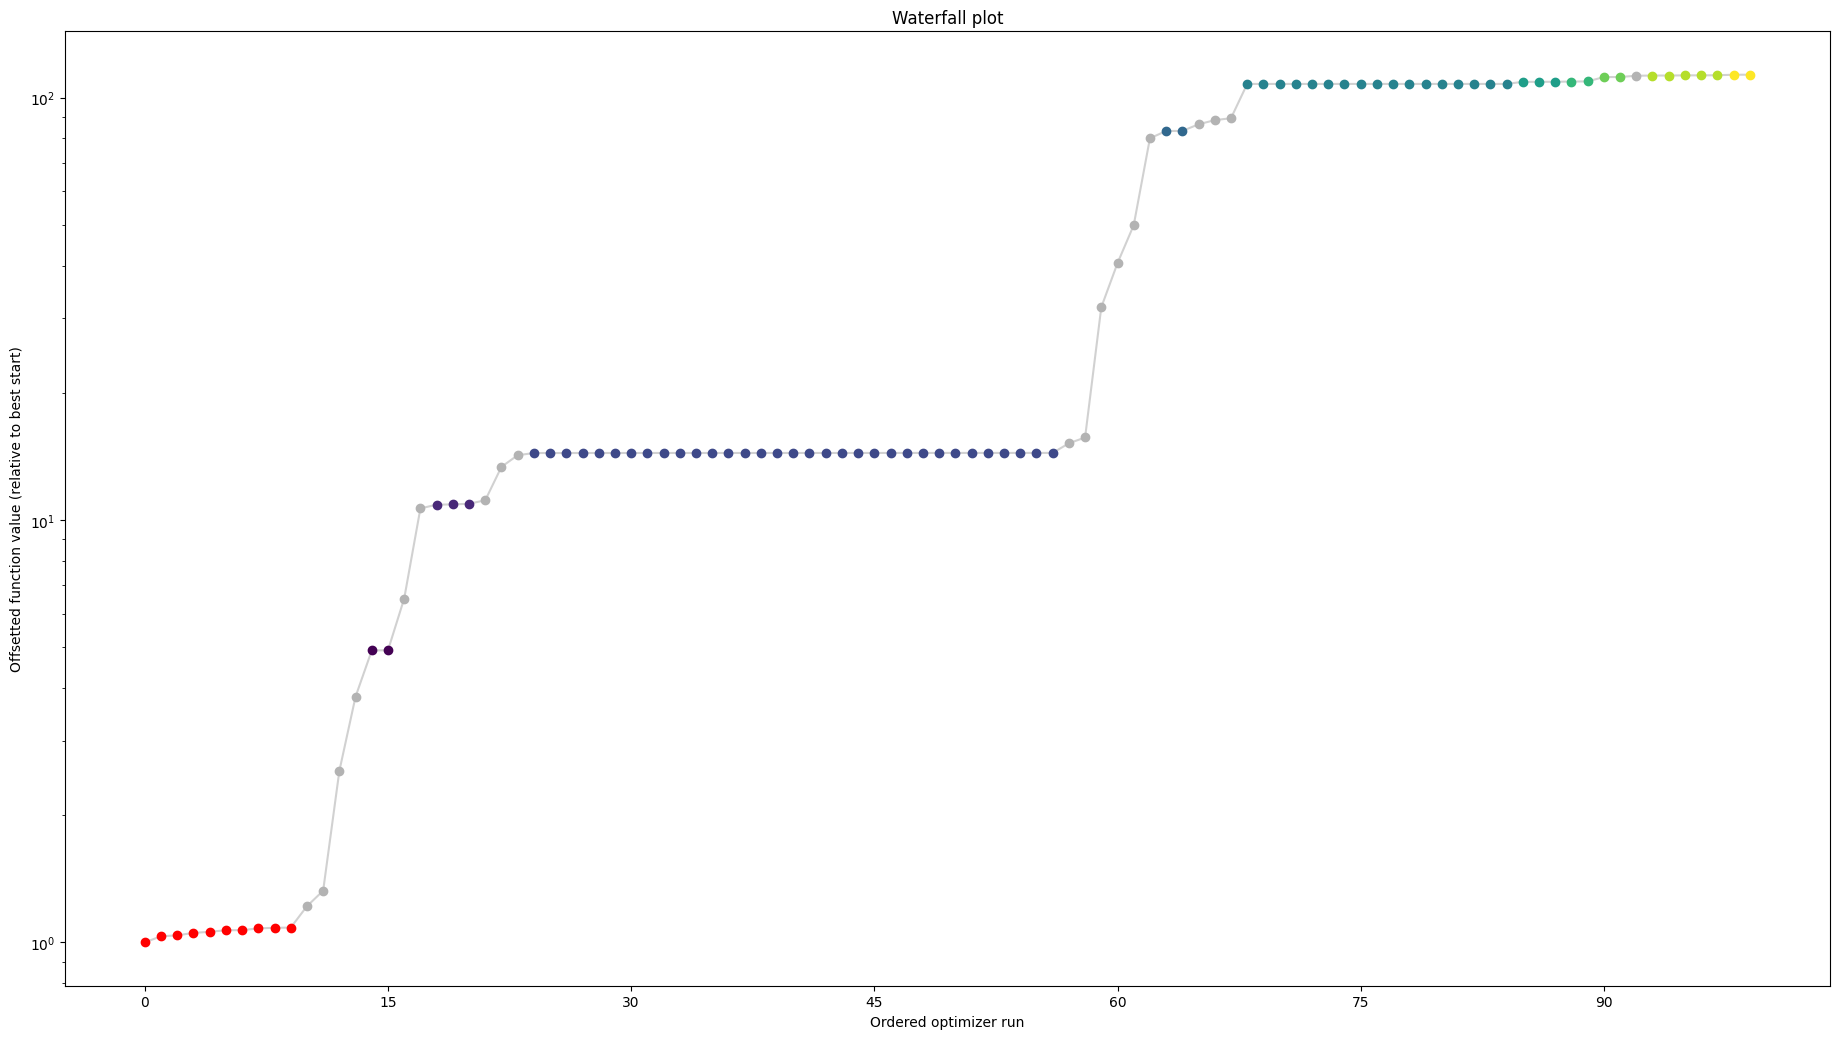

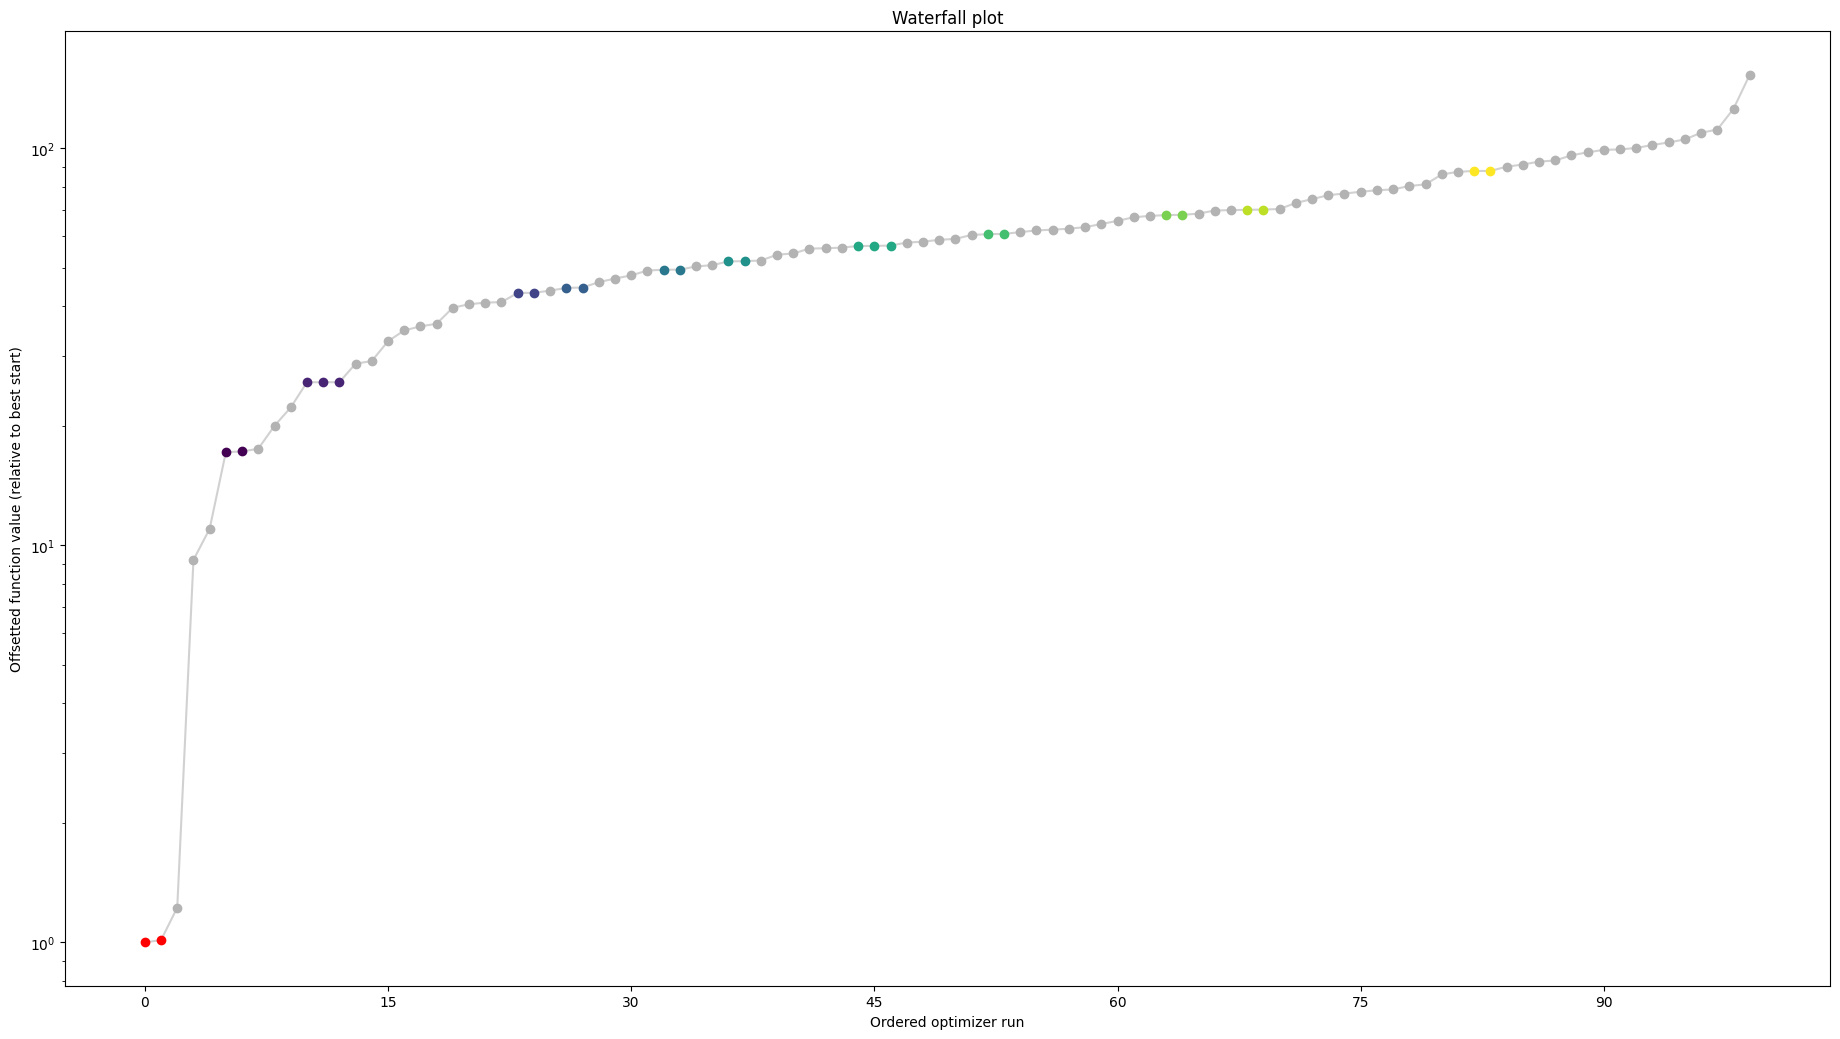

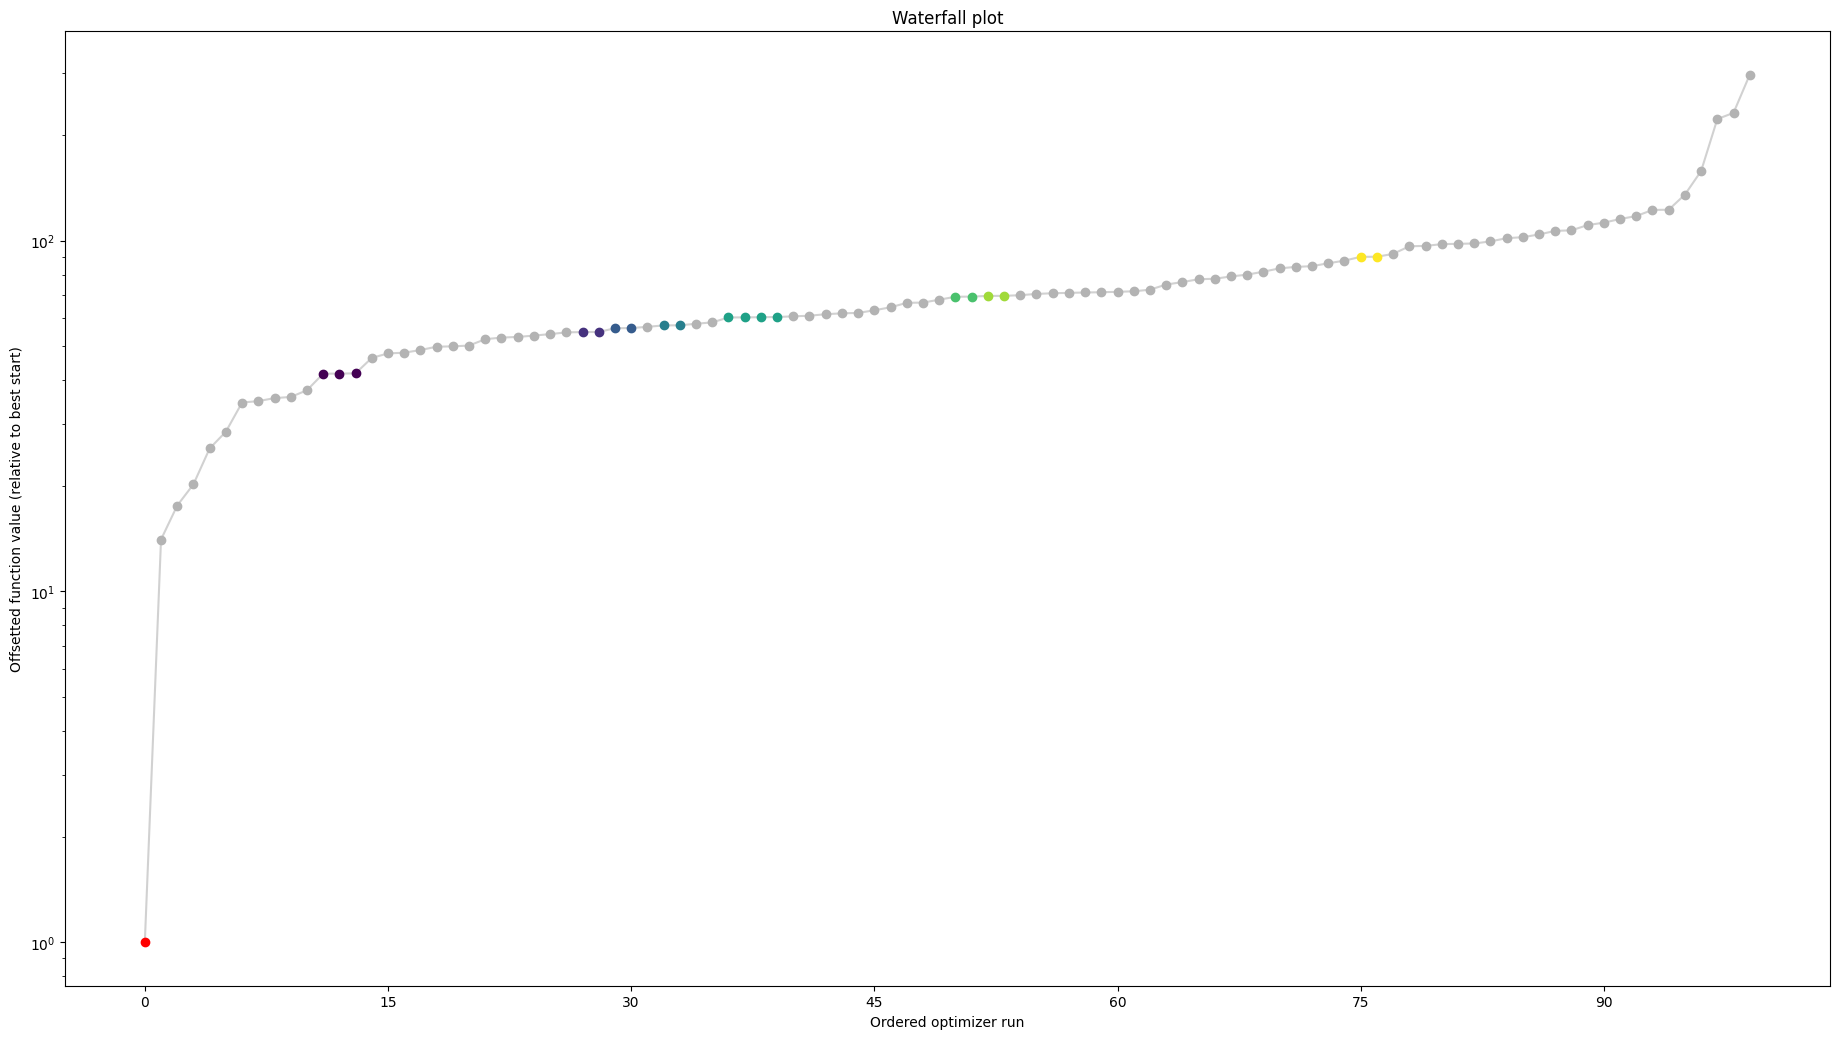

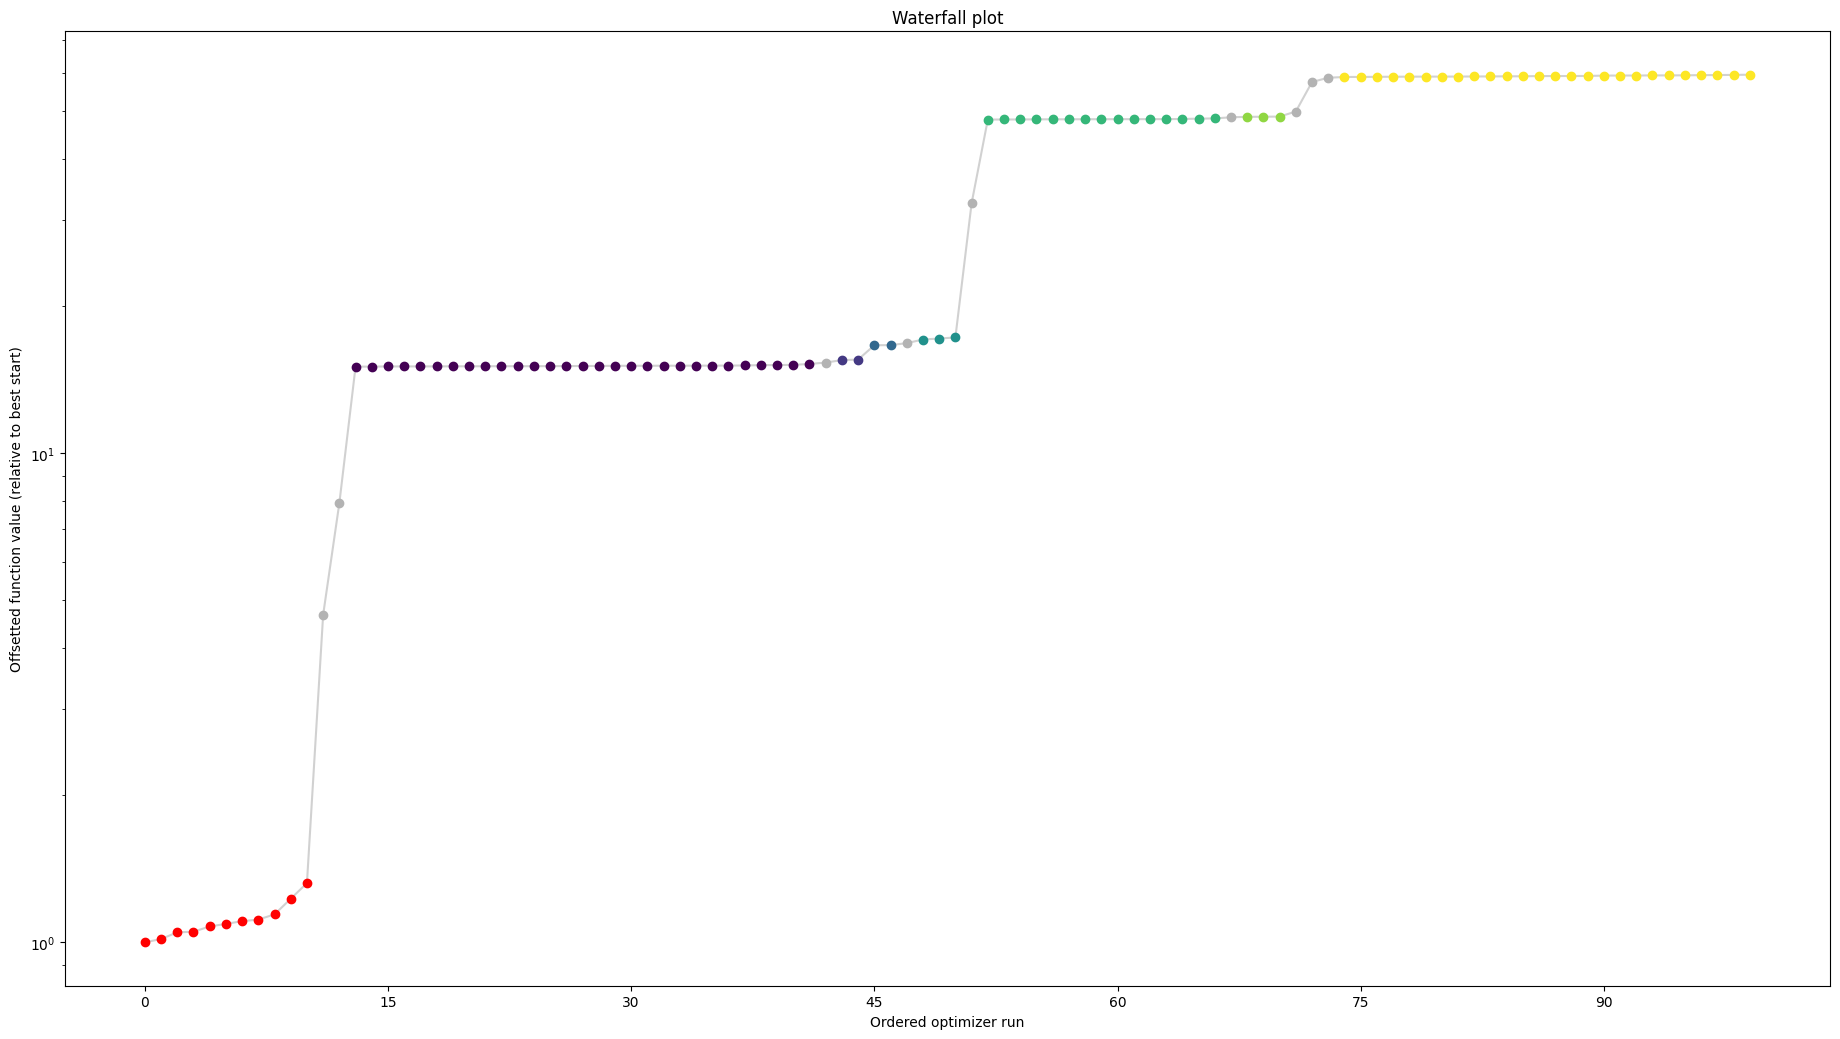

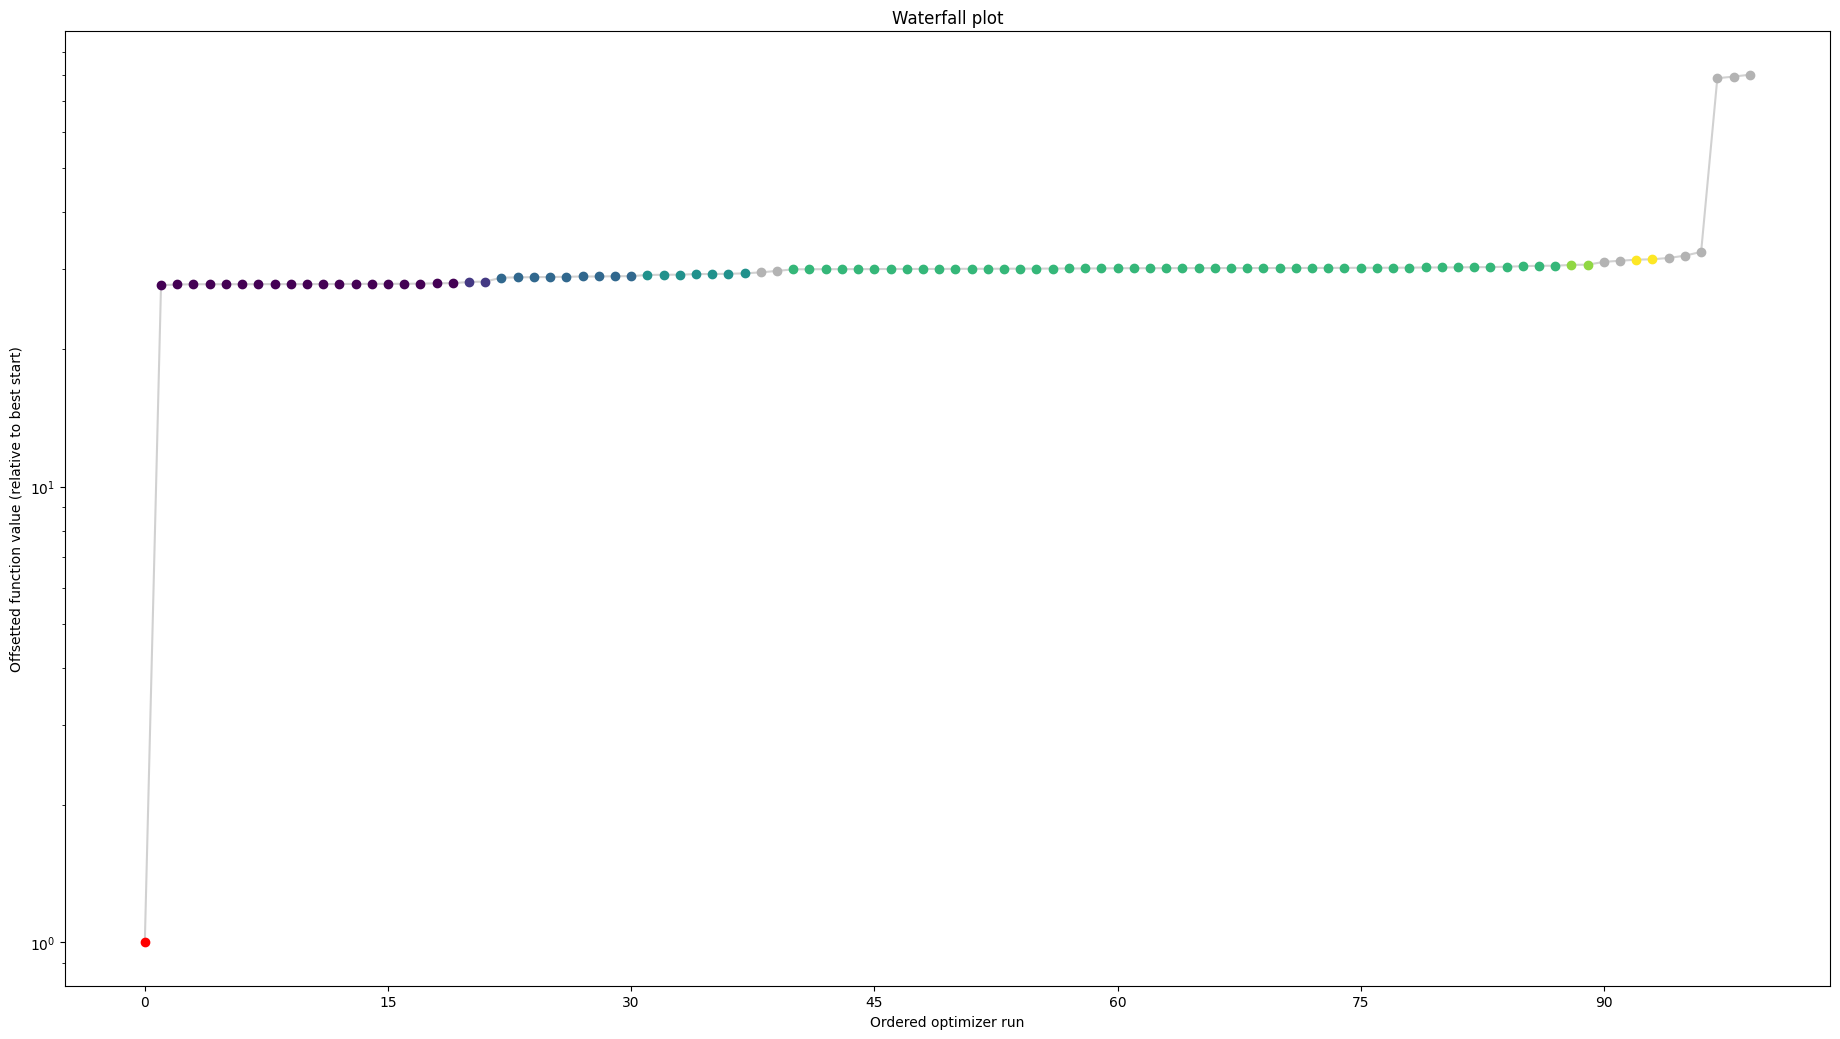

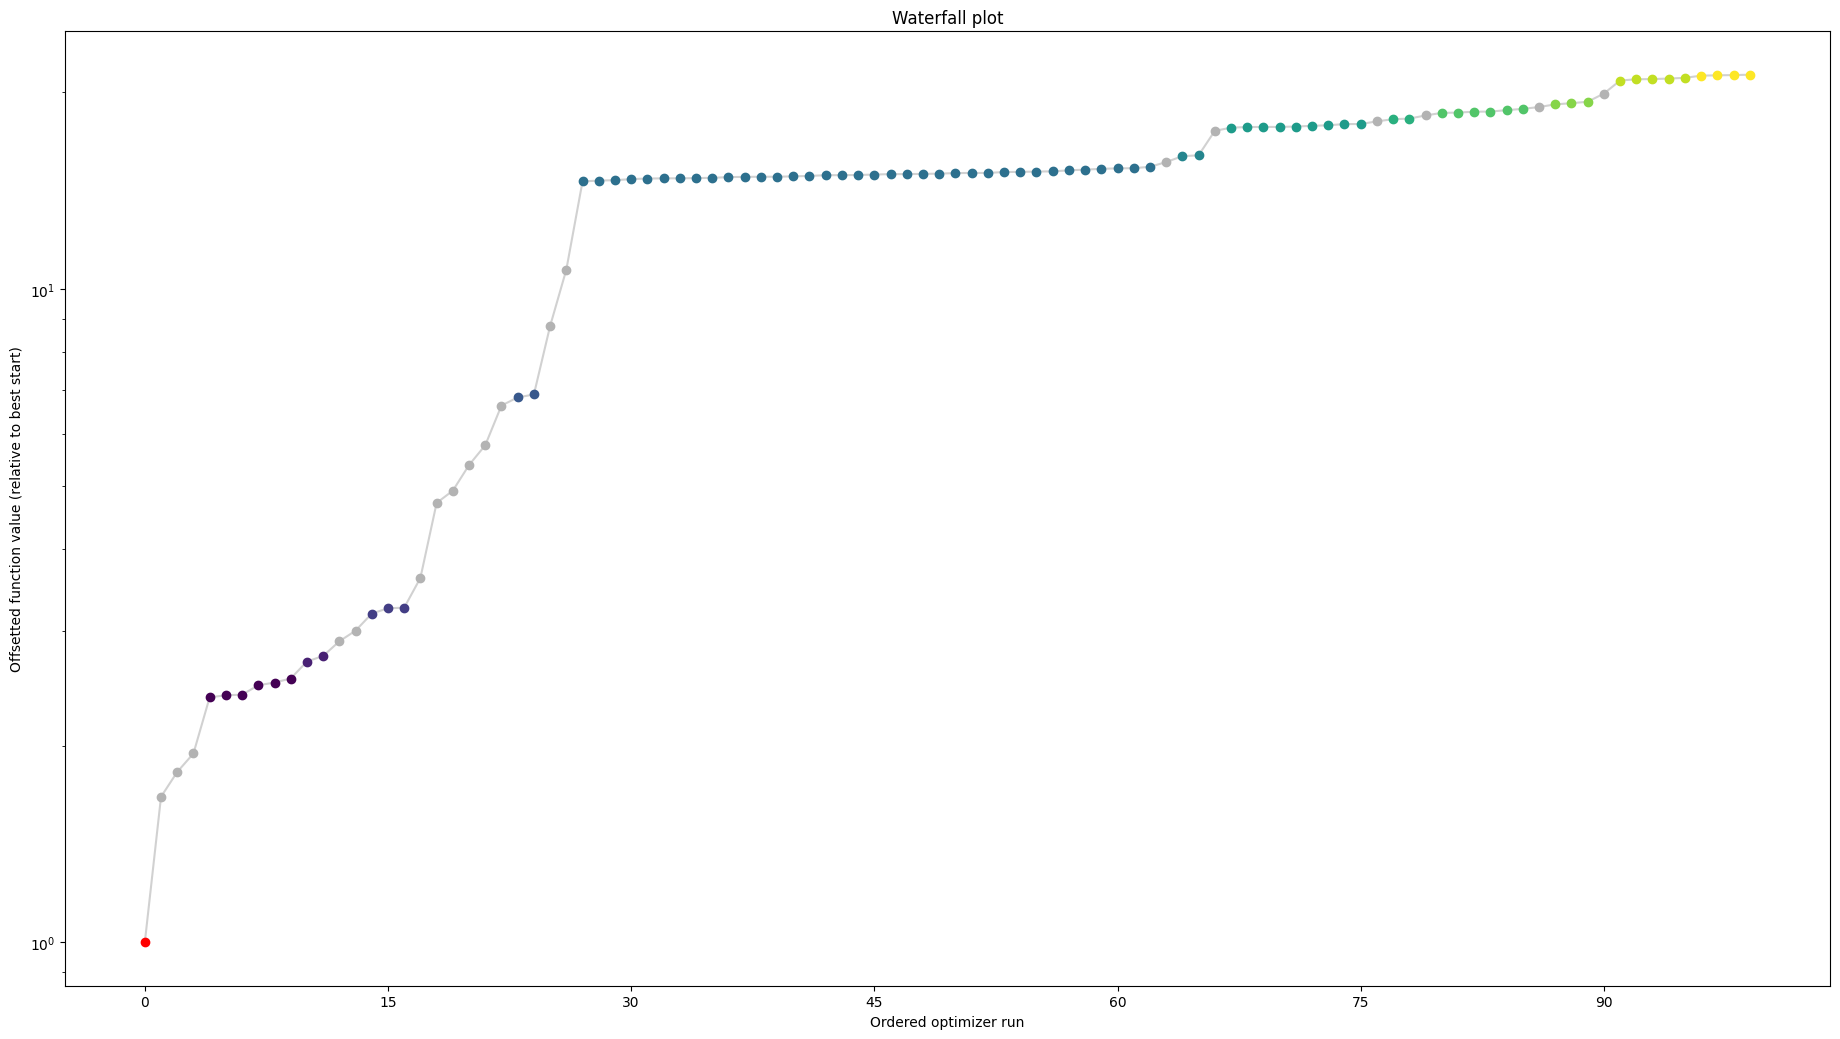

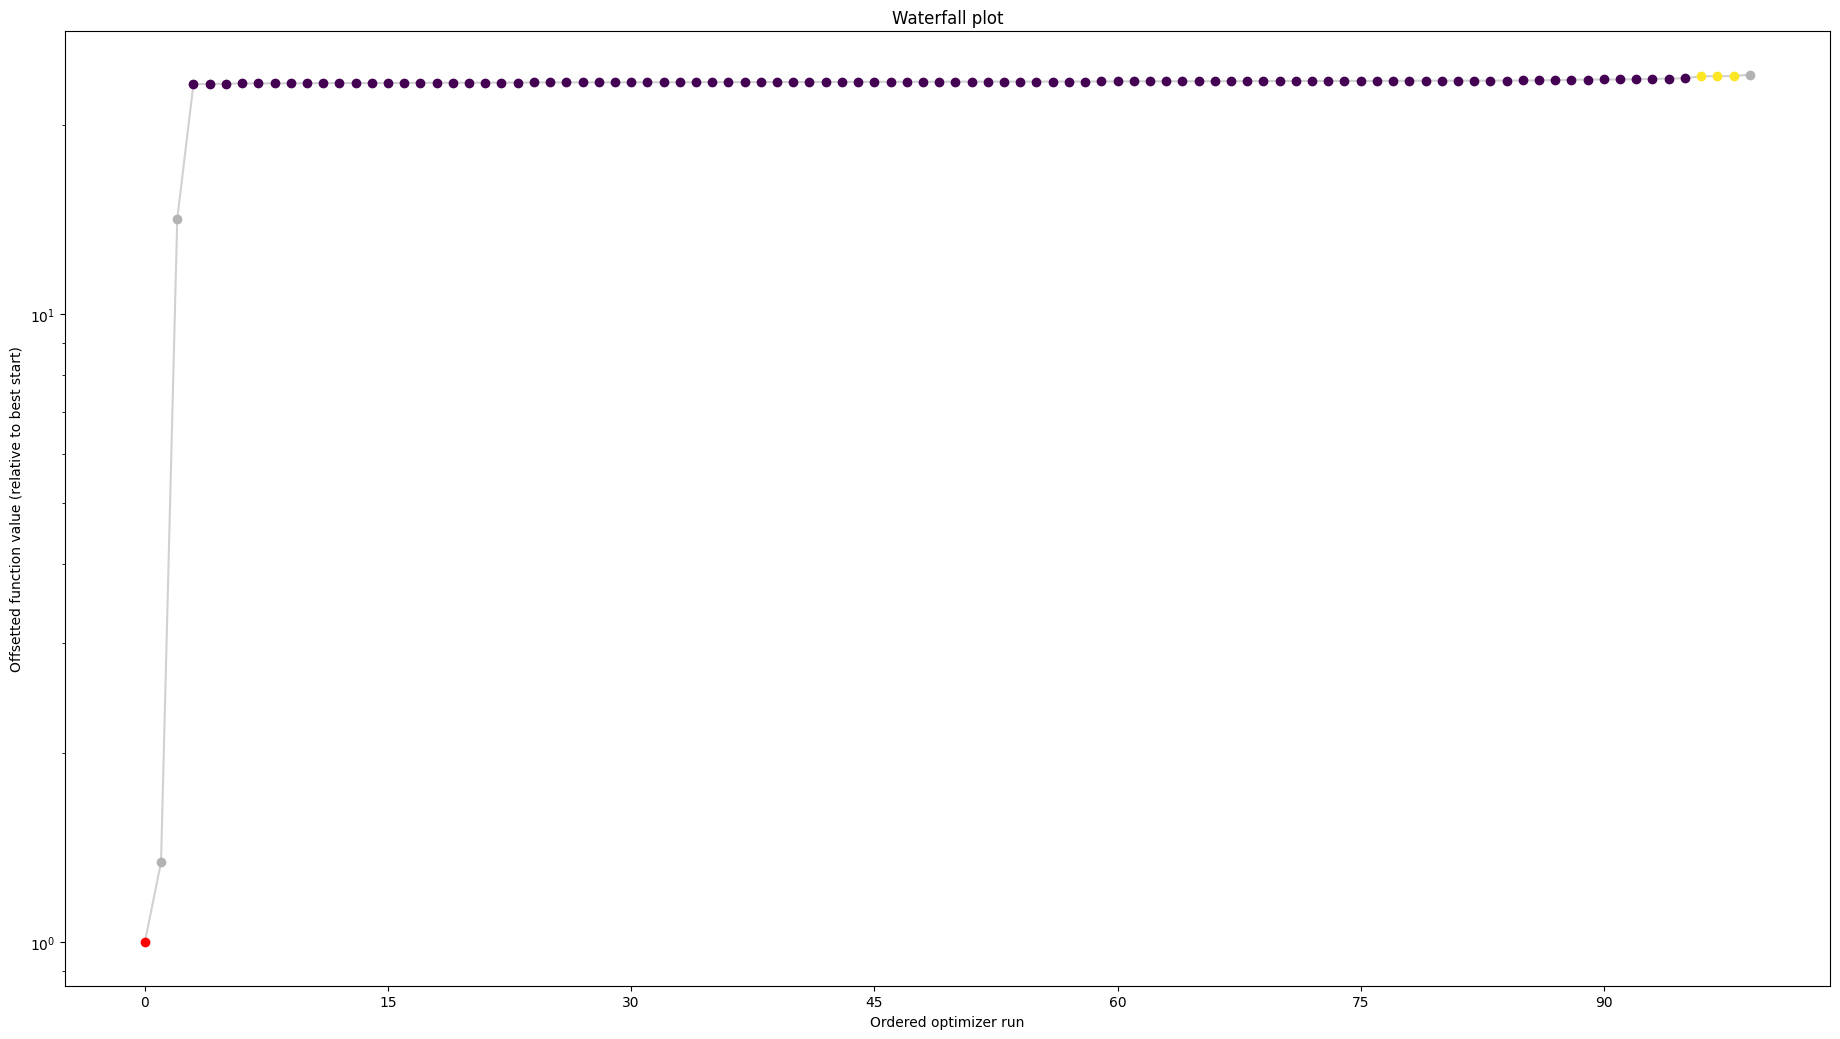

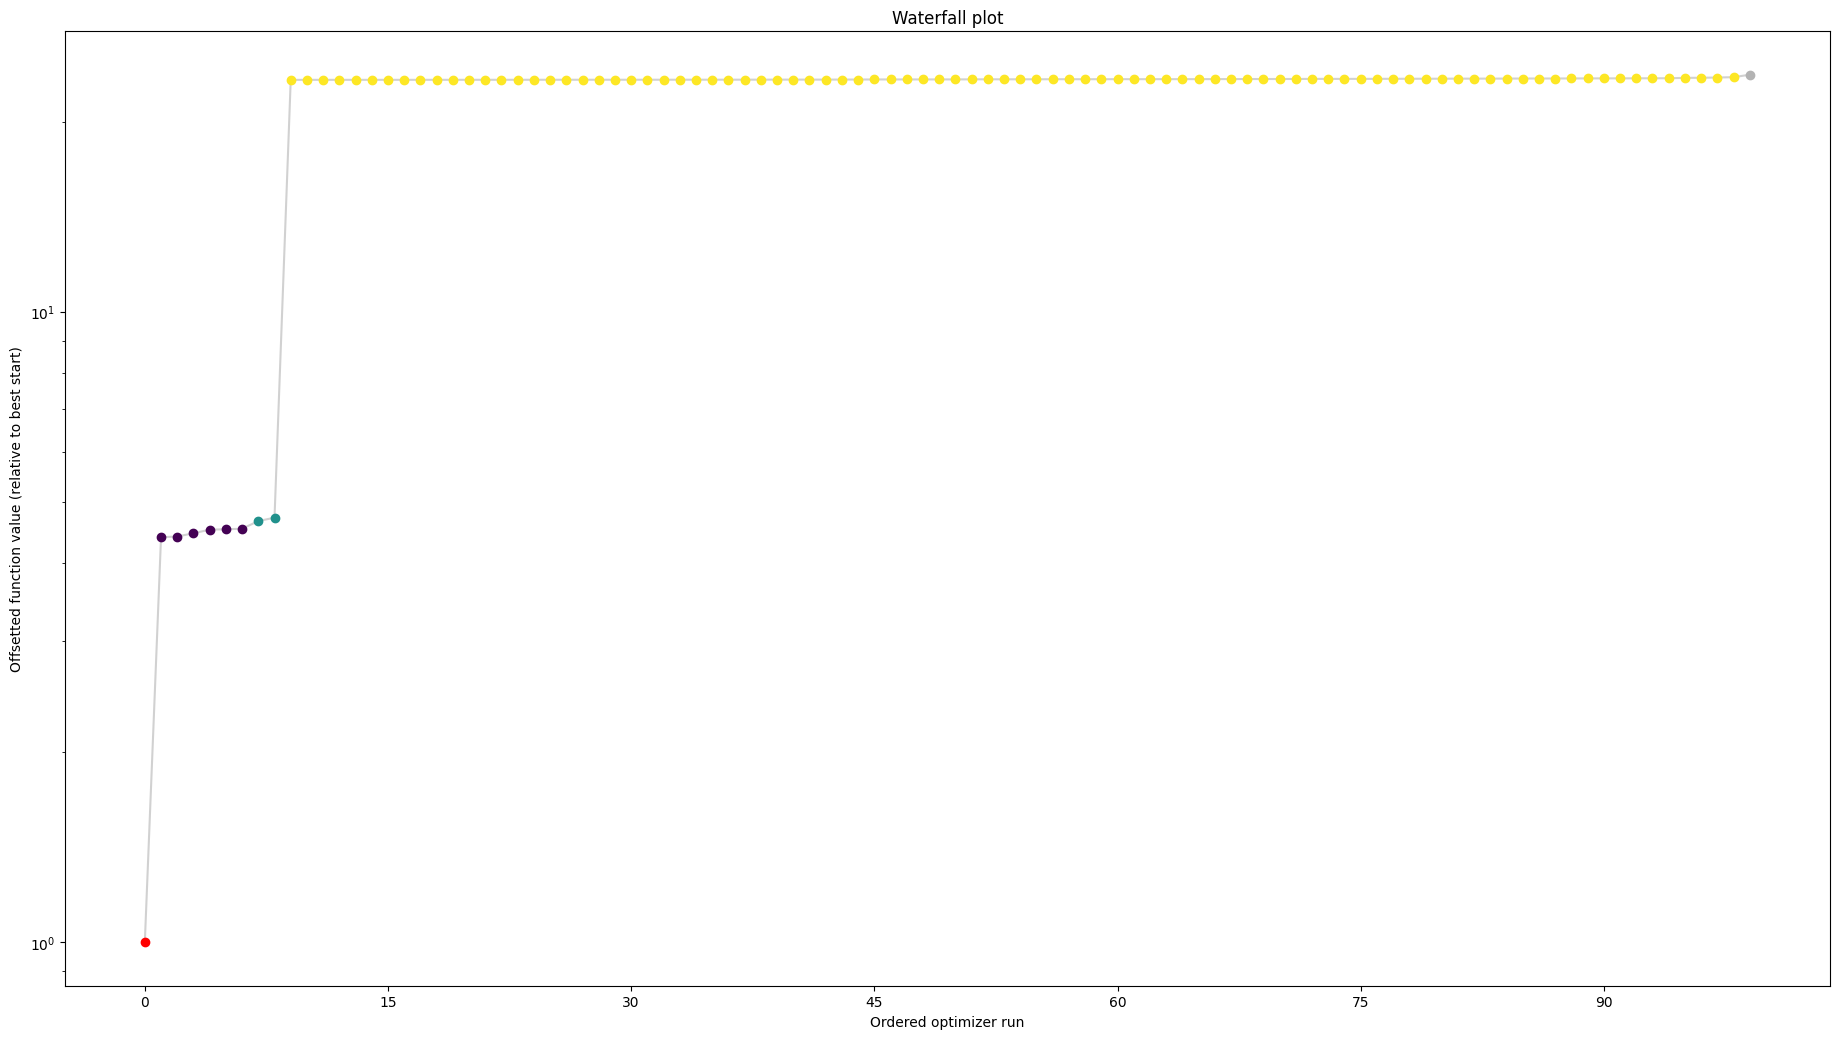

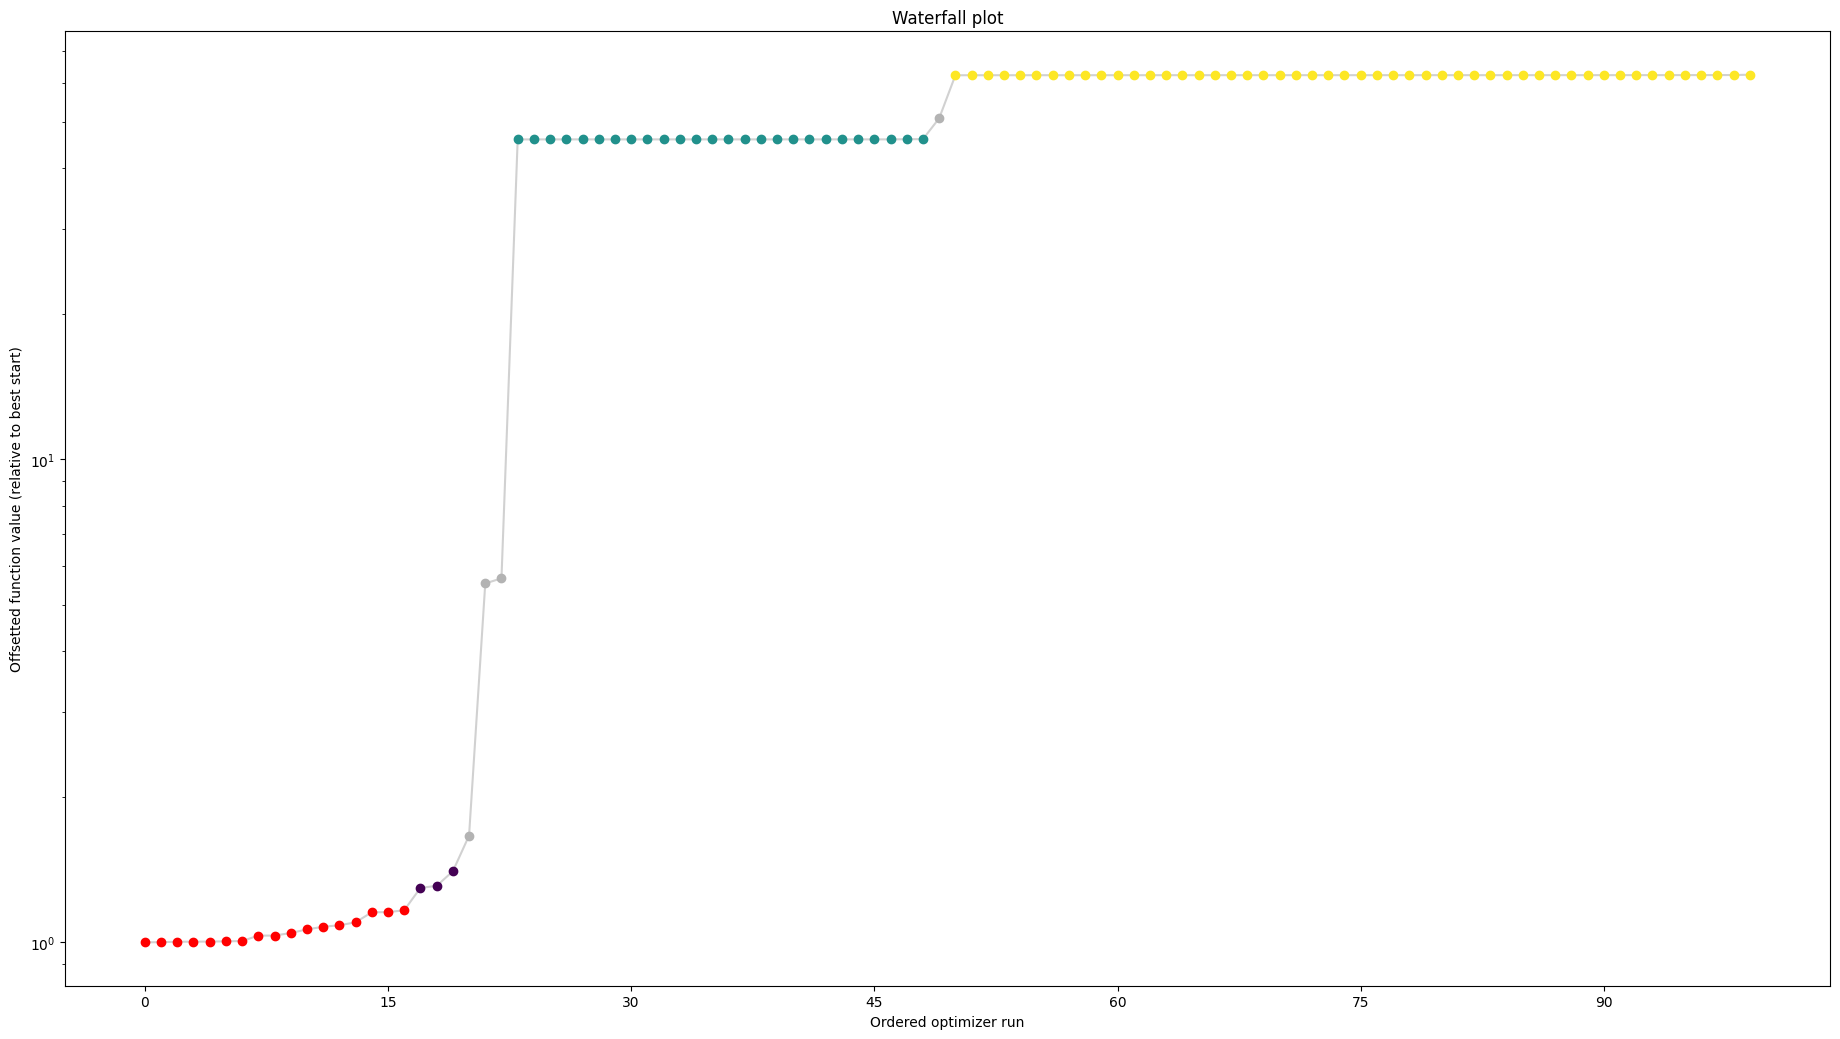

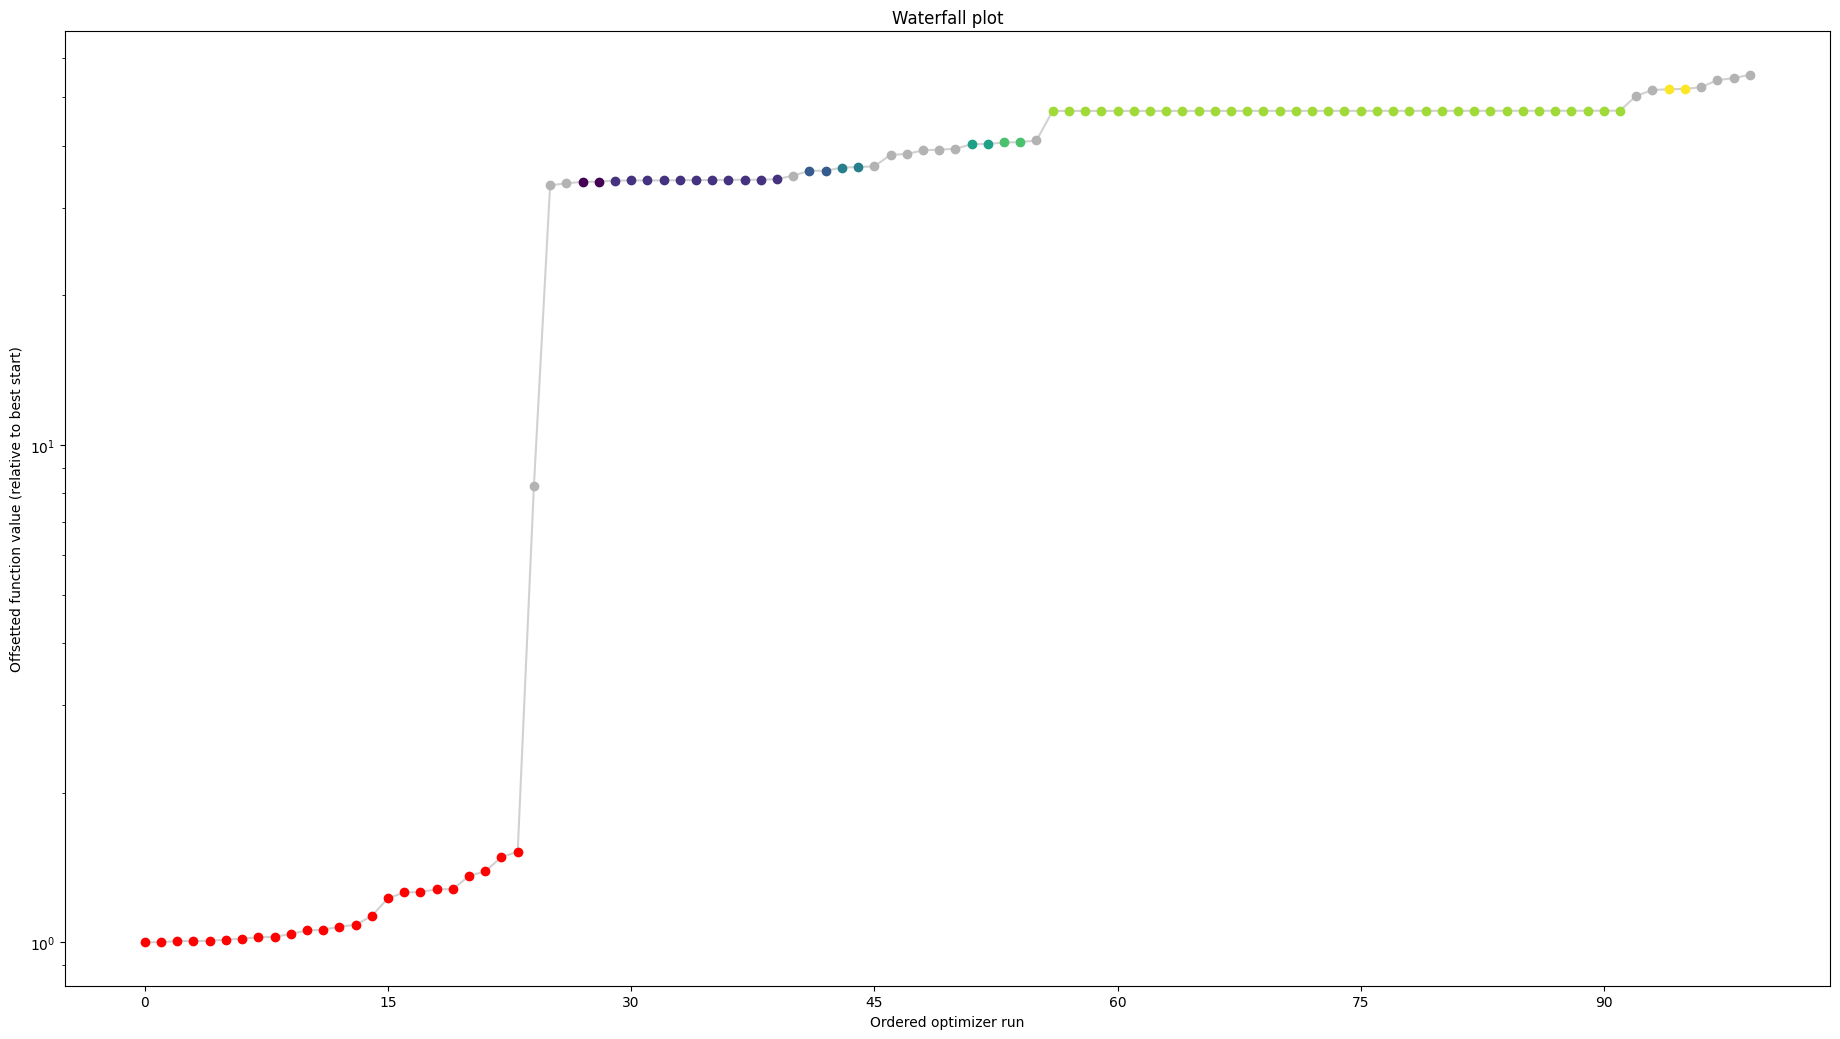

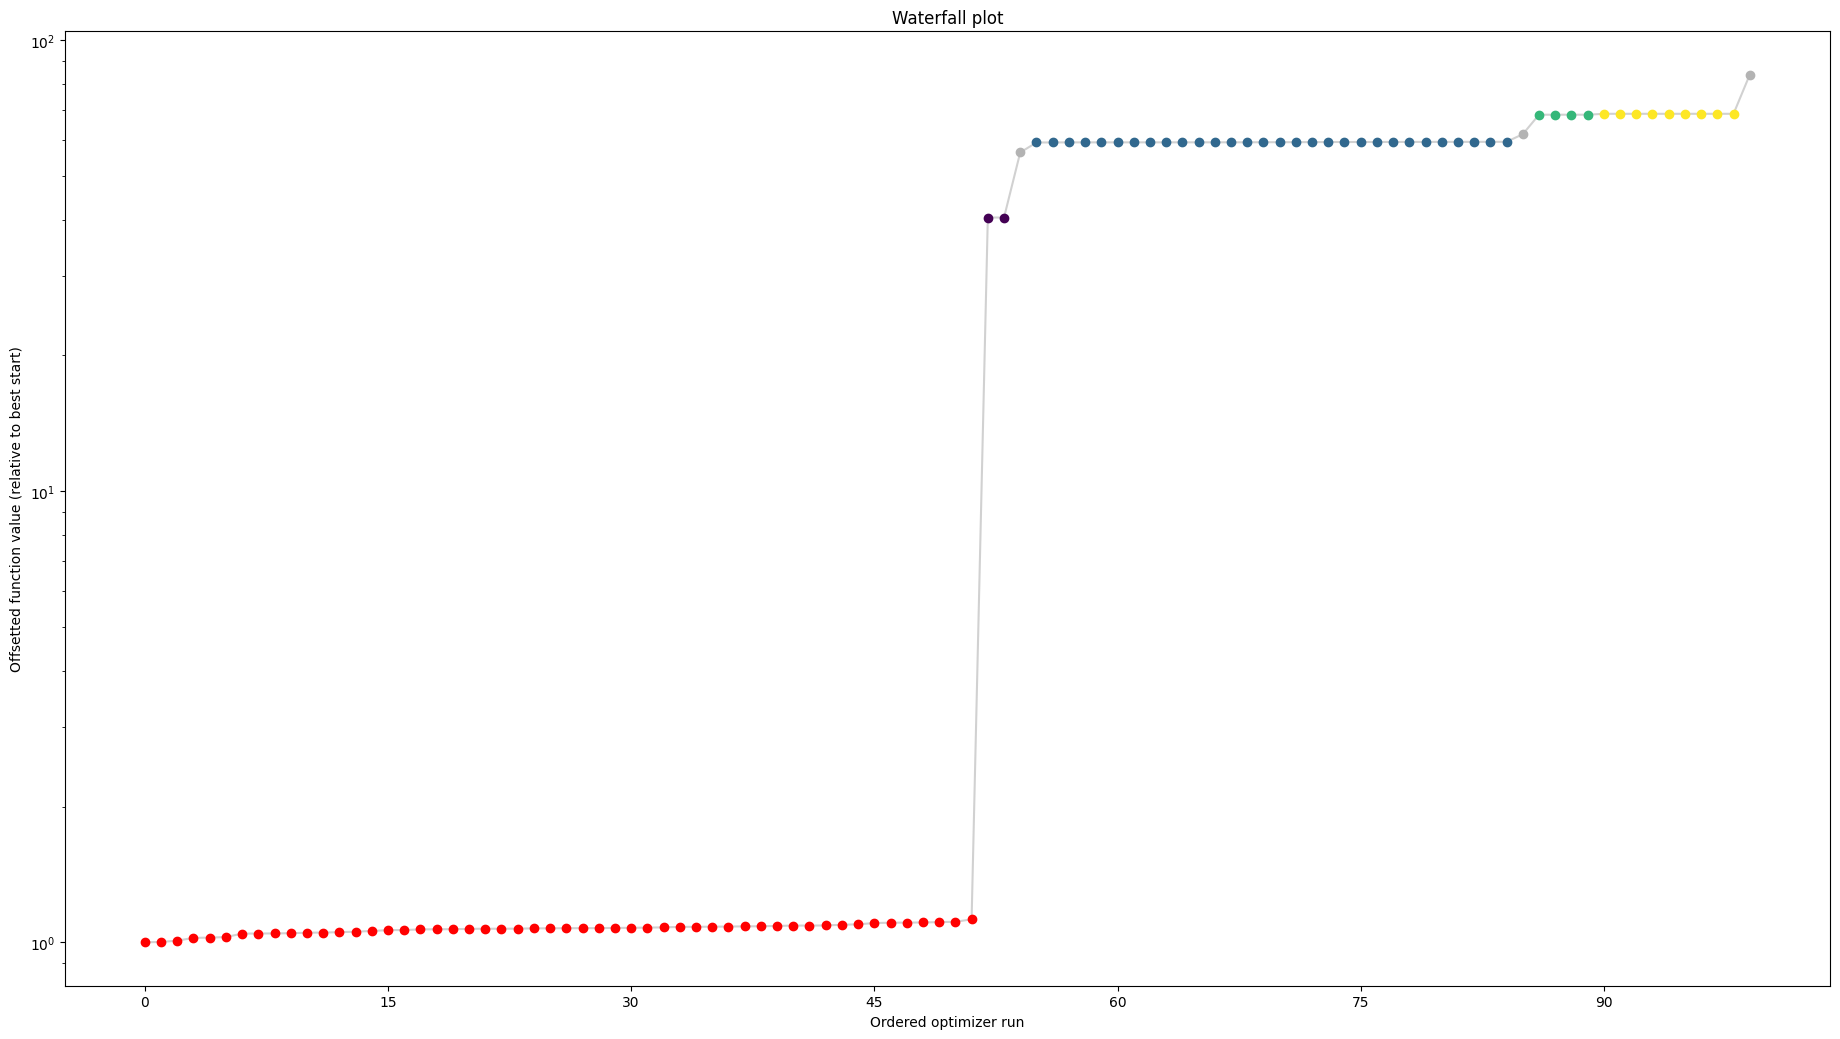

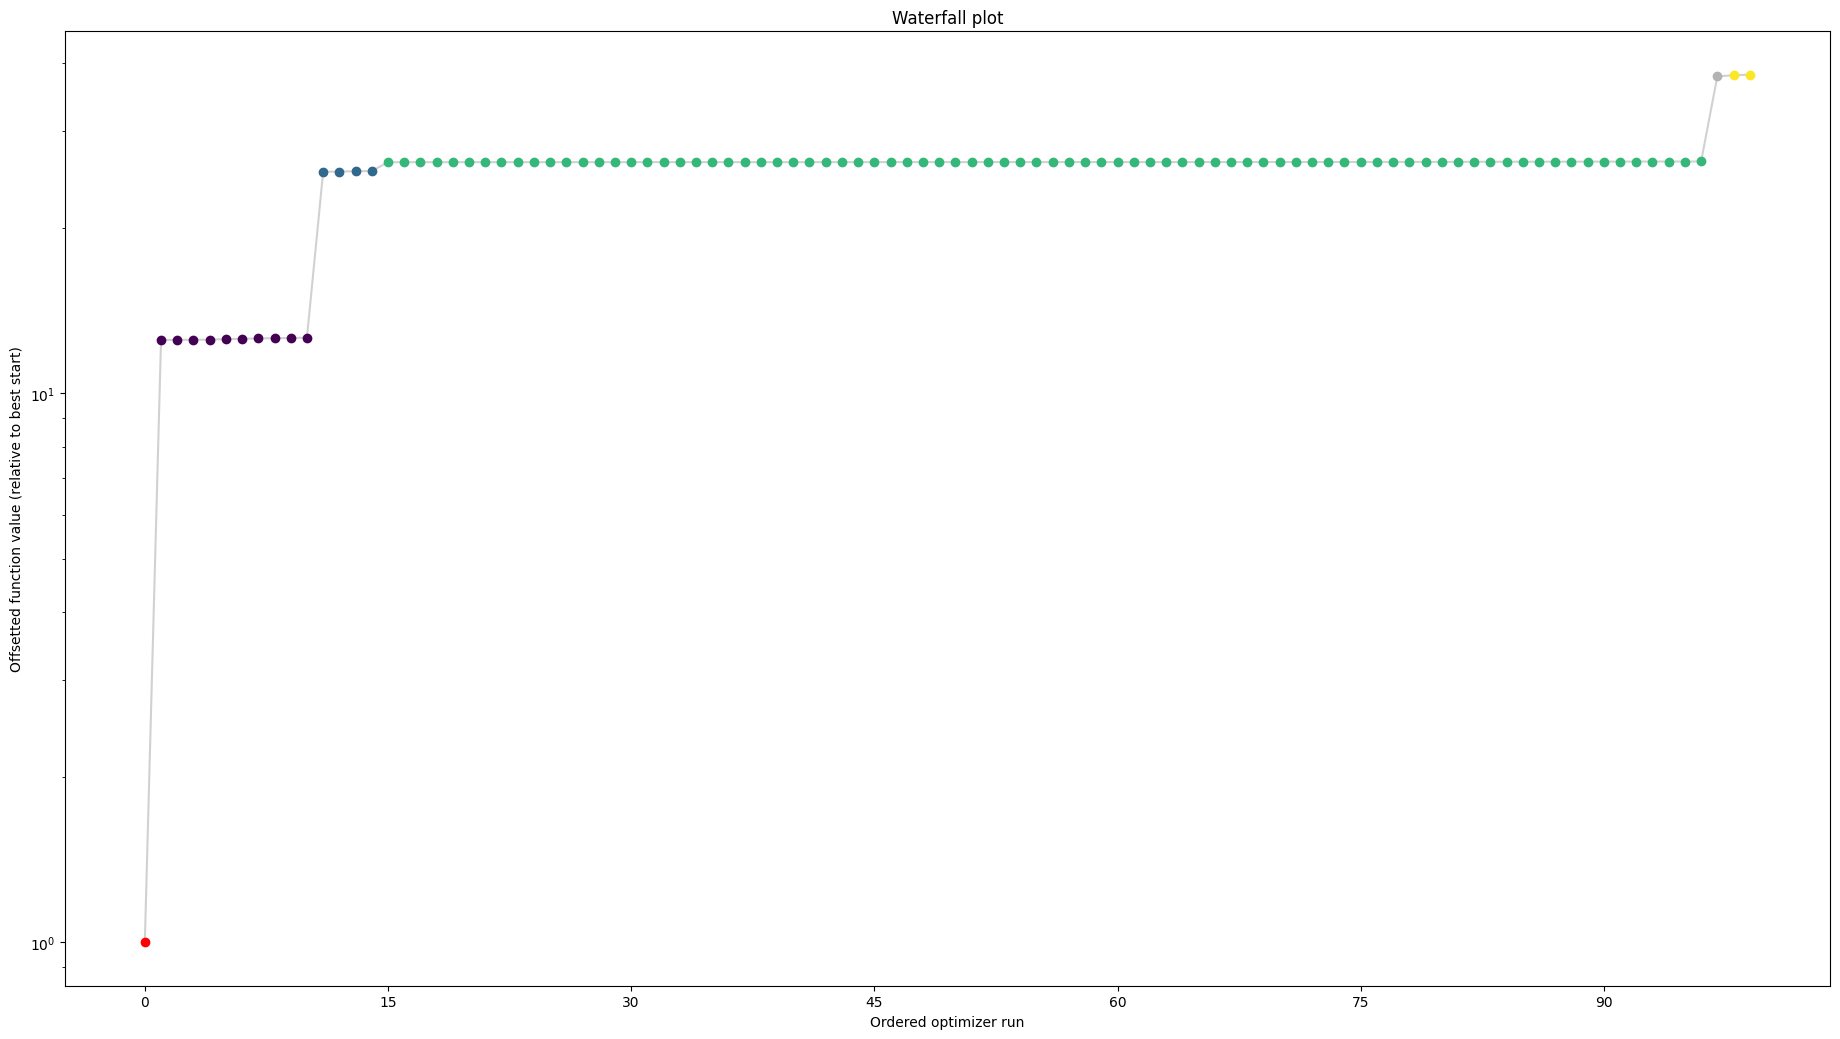

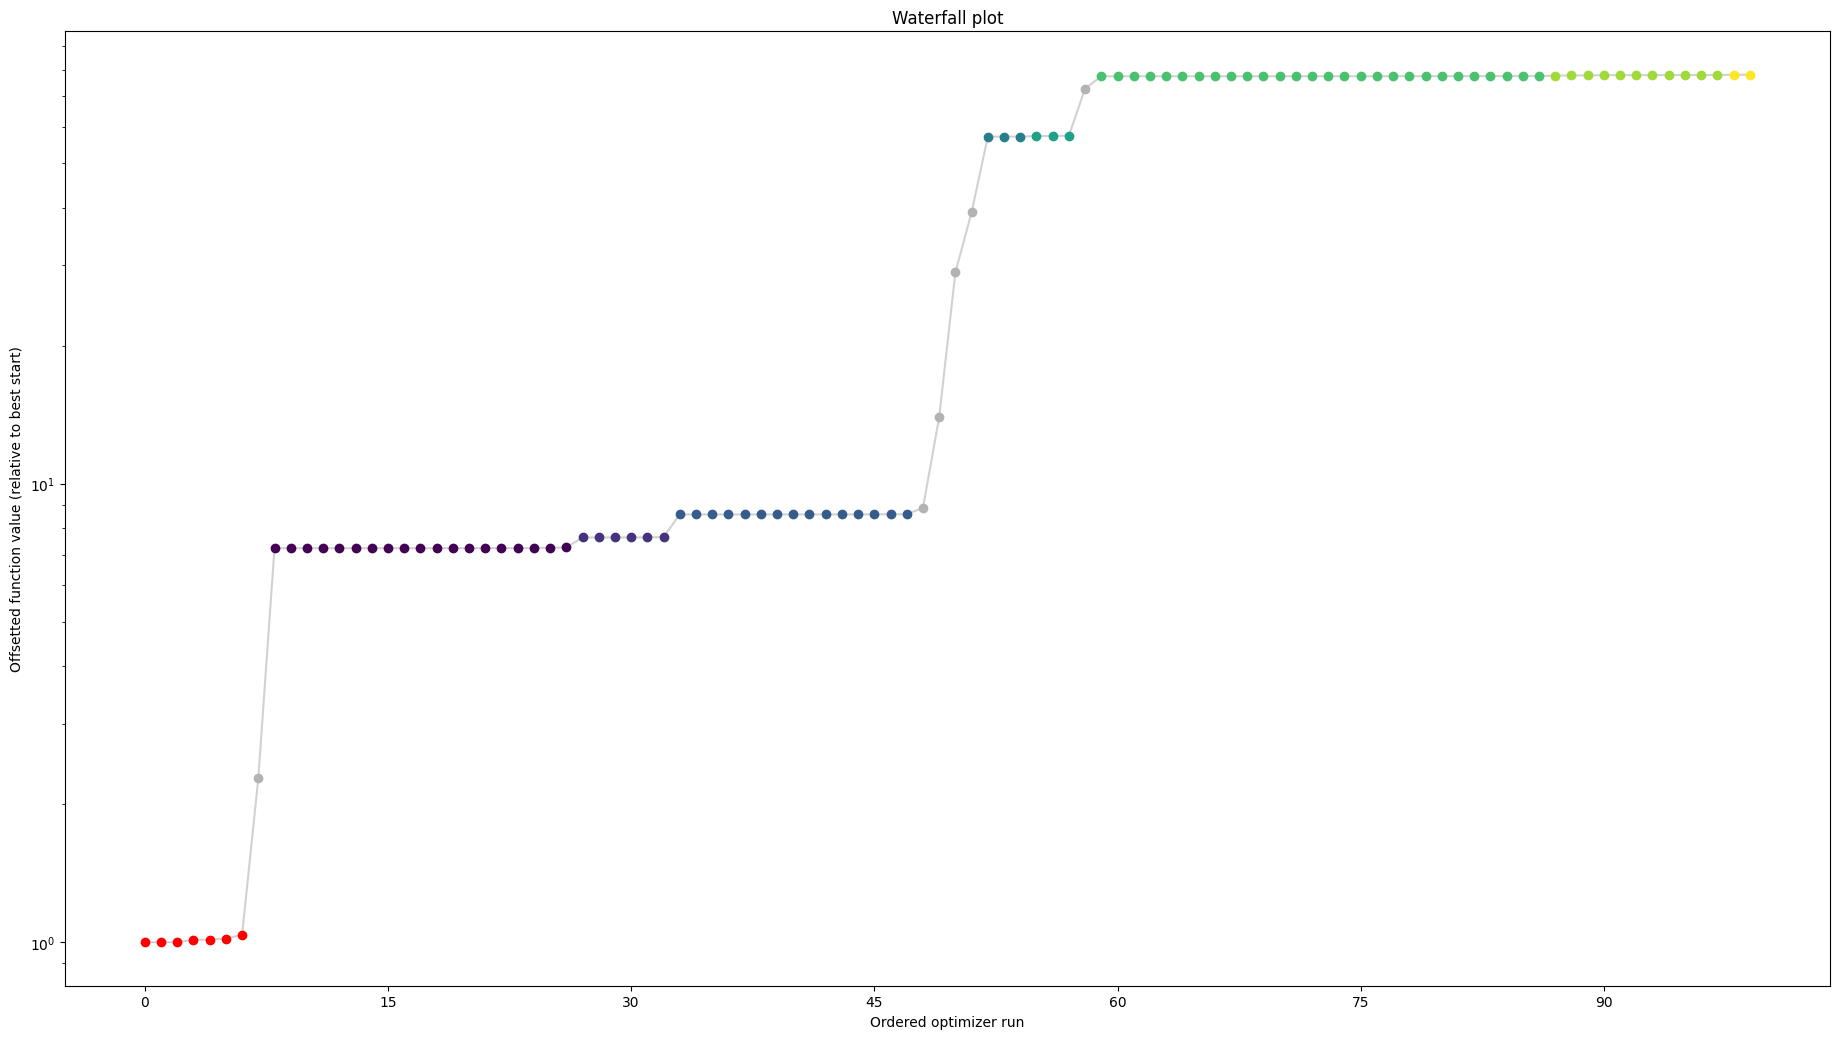

In [8]:
analyse("test")